In [ ]:





if __name__ == "__main__":

    start = time.perf_counter()

    


    print('CALCULATING THE REGION DENSITY')

    region_density.index.name = 'region'
    region_density_grouped = region_density.groupby('region').sum()
    region_density_grouped.reset_index(inplace=True, drop=False)


    region_density_grouped.loc[:, 'total_region'] = region_density_grouped.loc[:, COL].sum(axis=1)

    total_count_regions = region_density_grouped[['region', 'total_region']]

    region_density_grouped.drop(['total_region'], inplace=True, axis=1)
    region_density_grouped[COL] = region_density_grouped[COL] / total_records
    region_density_melted = pd.melt(region_density_grouped, id_vars=['region'], value_vars=COL)
    region_density_melted.rename(columns={'value': 'region_density'}, inplace=True)

    region_density_melted['variable'] = region_density_melted['variable'].astype(int)
    region_density_melted.rename(columns={'variable': 'position'}, inplace=True)
    region_density_melted['position'] = region_density_melted['position'] - 1000

    REGION_DENSITY_FILE = 'Region_density.csv'
    region_density_melted.to_csv(REGION_DENSITY_FILE)

    region_density_melted.sort_values(by=['position'], inplace=True, ascending=True)
    region_density_melted.reset_index(drop=True, inplace=True)

  
    # region_density_melted['nuc_region_density'] = region_density_melted.groupby('region')['region_density'].rolling(window=147,
    #                                                    min_periods=1, center=True).mean().reset_index(drop=True)
    # 
    # NUC_REGION_DENSITY_FILE = 'NUC_Region_density.csv'
    # region_density_melted.to_csv(NUC_REGION_DENSITY_FILE)
    region_density_grouped


    broken_axis_plot(data_ = region_density_melted,
                     plot_title = "Region density per base-pair position",
                     x_title='position w.r.t TSS',
                     y_title = 'density',
                     x_column = 'position',
                     y_column = 'nuc_region_density',
                     hue_column = 'region',
                     save_loc=NUCLO_ELEMENT_DENSITY_LINE_CHART, N=True)

    broken_axis_plot(data_=region_density_melted,
                     plot_title="Region density per base-pair position",
                     x_title='position w.r.t TSS',
                     y_title='density',
                     x_column='position',
                     y_column='region_density',
                     hue_column='region',
                     save_loc=ELEMENT_DENSITY_LINE_CHART,  N=False)


    import sys
    sys.exit()

    print('CALCULATING THE AVG GC CONTENT IN EACH REGION')

    region_gc_density.index.name = 'region'

    region_gc_density_grouped = region_gc_density.groupby('region').sum()
    region_gc_density_grouped.reset_index(inplace=True, drop=False)

    region_gc_density_grouped['region'] = region_gc_density_grouped['region'].map(OPP_REGION_DICT)
    region_gc_density_grouped.loc[:, 'gc_count'] = region_gc_density_grouped.loc[:, COL].sum(axis=1)

    region_gc_density_grouped.dropna(subset=['region'], axis=0, inplace=True)
    avg_gc_region_df = region_gc_density_grouped[['region', 'gc_count']]
    region_gc_density_grouped.drop(['gc_count'], axis=1, inplace=True)

    merged_avg_gc_region = avg_gc_region_df.merge(total_count_regions , on='region', how='left')
    merged_avg_gc_region['avg_gc'] = merged_avg_gc_region['gc_count'] / merged_avg_gc_region['total_region']
    merged_avg_gc_region['avg_gc'] = merged_avg_gc_region['avg_gc'].replace([np.inf, -np.inf], np.nan)

    AVG_GC_REGION_FILE = 'avg_gc.csv'
    merged_avg_gc_region.to_csv(AVG_GC_REGION_FILE) #### file location

    fig, ax3 = plt.subplots(figsize=(10, 7))
    sns.barplot(data=merged_avg_gc_region,
                x="region", y="avg_gc", ax=ax3, color='gray')
    plt.xlabel("Region", fontsize=9)
    plt.ylabel("GC content", fontsize=9)
    plt.title("Average GC content per region", size=10, fontweight='bold')
    plt.tick_params(axis='both', labelrotation=0, labelsize=8)
    plt.grid(linestyle='--', linewidth=0.5, axis='y')
    plt.savefig(AVG_GC_REGION_CHART)



    print('INTER-REGION SIGNAL PER REGION, CALCULATING THE AVG GC CONTENT FROM EACH REGION PER BASE PAIR')

    inter_region_signal = region_density_melted.merge(merged_avg_gc_region[['region', 'avg_gc']],
                                               on='region',
                                               how='left')
    inter_region_signal['signal'] = inter_region_signal['region_density'] * inter_region_signal['avg_gc']

    INTER_SIGNAL_REGION_DIST_FILE = 'Inter_signal_per_region.csv'
    inter_region_signal.to_csv(INTER_SIGNAL_REGION_DIST_FILE)

    # broken_axis_plot(data_=inter_region_signal,
    #                  plot_title="Average GC content distribution per region per base-pair position (Inter-region signal)",
    #                  x_title='position w.r.t TSS',
    #                  y_title='GC content',
    #                  x_column='position',
    #                  y_column='signal',
    #                  hue_column='region',
    #                  save_loc=NUCLO_INTER_SIGNAL_REGION_DIST_CHART, N=True)

    broken_axis_plot(data_=inter_region_signal,
                     plot_title="Average GC content distribution per region per base-pair position (Inter-region signal)",
                     x_title='position w.r.t TSS',
                     y_title='GC content',
                     x_column='position',
                     y_column='signal',
                     hue_column='region',
                     save_loc=INTER_SIGNAL_REGION_DIST_CHART, N=False)







    print('TOTAL INTER-REGION SIGNAL PER BASE PAIR')

    total_inter_region_signal = inter_region_signal.groupby('position')['signal'].sum()
    total_inter_region_signal = total_inter_region_signal.reset_index()
    total_inter_region_signal.rename(columns={'signal': 'inter_signal'}, inplace=True)
    total_inter_region_signal.to_csv(AVG_GC_DENSITY_BY_REGION_FILE)




    print('INTRA-SIGNAL PER REGION,  Calculating the Region Specific GC content per base pair average across ALL transcripts')

    region_gc_density_grouped[COL] = region_gc_density_grouped[COL] / total_records
    region_gc_density_grouped_melted = pd.melt(region_gc_density_grouped, id_vars=['region'], value_vars=COL)
    region_gc_density_grouped_melted.rename(columns={'value': 'intra_signal',
                                                     'variable': 'position'}, inplace=True)

    region_gc_density_grouped_melted['position'] = region_gc_density_grouped_melted['position'].astype(int)
    region_gc_density_grouped_melted['position'] = region_gc_density_grouped_melted['position'] - 1000

    region_gc_density_grouped_melted.to_csv(GC_PER_REGION_PER_BP_ALL_TRANS_FILE) ### Intermediate File before centering the data


    region_gc_density_grouped_melted['intra_signal'] = region_gc_density_grouped_melted.apply(make_nan, value_col='intra_signal', axis=1)

    intra_mean_data = region_gc_density_grouped_melted.groupby(['region'])['intra_signal'].mean()
    intra_mean_data = intra_mean_data.reset_index()

    intra_mean_data.rename(columns={'intra_signal': 'mean_intra_signal'}, inplace=True)

    cent_region_gc_density_grouped_melted = region_gc_density_grouped_melted.merge(intra_mean_data, on='region', how='left')
    cent_region_gc_density_grouped_melted['cent_intra_signal'] = cent_region_gc_density_grouped_melted['intra_signal'] - \
                                                           cent_region_gc_density_grouped_melted['mean_intra_signal']

    cent_region_gc_density_grouped_melted.to_csv(CENTERED_GC_DENSITY_BY_REGION_FILE)

    colormap_region = {'D': 'blue', 'E': 'red', 'I': 'orange', 'U': 'green', 'F': 'cyan', 'f': 'gray'}
    region_labels = {'D': "3'UTR", 'E': "CDS", 'I': "Intron", 'U': "5'UTR", 'F': "5'end", 'f': "3'end"}

    fig, ax2 = plt.subplots(figsize=(10, 7))
    sns.scatterplot(data=cent_region_gc_density_grouped_melted, x='position', y="cent_intra_signal", hue='region', fc='none',
                    ec=cent_region_gc_density_grouped_melted["region"].map(colormap_region),
                    palette=colormap_region, s=1.5, linewidth=1, ax=ax2)
    handles, labels = ax2.get_legend_handles_labels()
    new_labels = [region_labels.get(item, item) for item in labels]

    ax2.set_xlabel("position w.r.t TSS", fontsize=9)
    ax2.set_ylabel("GC content", fontsize=9)
    ax2.set_title("Region wise GC content distribution per base-pair position (Intra-region signal)", size=10, fontweight='bold')
    ax2.set_xticks(np.arange(-1000, 1000, 100))
    ax2.tick_params(axis='both', labelrotation=0, labelsize=8)
    ax2.legend(handles=handles, loc='upper right', fontsize=8, labels=new_labels)
    ax2.set_xlim(-1000, 1000, 100)
    ax2.grid(linestyle='--', linewidth=0.5)

    plt.savefig(INTRA_SIGNAL_REGION_DIST_CHART)


    # if NUC:
    #     plt.axvline(73, linestyle='dotted', color='m')
    #     plt.savefig(NUCLO_INTRA_SIGNAL_REGION_DIST_CHART)
    # else:
    #     plt.savefig(INTRA_SIGNAL_REGION_DIST_CHART)



    print('NORMALISED INTRA-REGION SIGNAL, CALCULATING THE GC CONTENT PER EACH REGION PER BASE PAIR')

    region_gc_density_grouped_melted_joined_region_den = region_gc_density_grouped_melted.merge(region_density_melted,
                                                                                    on=['region', 'position'],
                                                                                    how='left')
    region_gc_density_grouped_melted_joined_region_den['normalised_intra_signal'] = region_gc_density_grouped_melted_joined_region_den[
                                                                              'intra_signal'] / \
                                                                          region_gc_density_grouped_melted_joined_region_den[
                                                                              'region_density']

    region_gc_density_grouped_melted_joined_region_den['normalised_intra_signal'].fillna(0, inplace=True)
    region_gc_density_grouped_melted_joined_region_den.to_csv(GC_PER_REGION_PER_BP_FILE) ### Intermittent file

    print(region_gc_density_grouped_melted_joined_region_den)

    region_gc_density_grouped_melted_joined_region_den['normalised_intra_signal'] = region_gc_density_grouped_melted_joined_region_den.apply(make_nan, value_col='normalised_intra_signal', axis=1)

    norm_intra_mean_data = region_gc_density_grouped_melted_joined_region_den.groupby(['region'])['normalised_intra_signal'].mean()
    norm_intra_mean_data = norm_intra_mean_data.reset_index()

    norm_intra_mean_data.rename(columns={'normalised_intra_signal': 'mean_intra_signal'}, inplace=True)

    cent_region_gc_density_grouped_melted_joined_region_den = region_gc_density_grouped_melted_joined_region_den.merge(norm_intra_mean_data, on='region',
                                                                                   how='left')
    cent_region_gc_density_grouped_melted_joined_region_den['cent_norm_intra_signal'] = cent_region_gc_density_grouped_melted_joined_region_den['normalised_intra_signal'] - \
                                                                 cent_region_gc_density_grouped_melted_joined_region_den[
                                                                     'mean_intra_signal']

    cent_region_gc_density_grouped_melted_joined_region_den.to_csv(CENTERED_GC_PER_REGION_PER_BP_FILE)


    fig, ax1 = plt.subplots(figsize=(10, 7))
    cent_region_gc_density_grouped_melted_joined_region_den = cent_region_gc_density_grouped_melted_joined_region_den.fillna(0)

    sns.scatterplot(data=cent_region_gc_density_grouped_melted_joined_region_den, x='position', y="cent_norm_intra_signal", hue='region',
                    fc='none', ec=cent_region_gc_density_grouped_melted_joined_region_den["region"].map(colormap_region),
                    palette=colormap_region, s=1.5, linewidth=1, ax=ax1)
    handles, labels = ax1.get_legend_handles_labels()
    new_labels = [region_labels.get(item, item) for item in labels]
    plt.xlabel("position w.r.t TSS", fontsize=9)
    plt.ylabel("GC content", fontsize=9)
    plt.title("Region wise GC content distribution per region-specific base-pair position (Normalised Intra-region signal)", size=10, fontweight='bold')
    plt.xticks(np.arange(-1000, 1000, 100))
    plt.tick_params(axis='both', labelrotation=0, labelsize=8)
    plt.legend(handles=handles, loc='upper right', fontsize=8, labels=new_labels)
    plt.xlim(-1000, 1000, 100)
    plt.grid(linestyle='--', linewidth=0.5)

    # if NUC:
    #     plt.axvline(73, linestyle='dotted', color='m')
    #     plt.savefig(NUCLO_INTRA_SIGNAL_REGION_DIST_PERBP_CHART)
    # else:
    #     plt.savefig(INTRA_SIGNAL_REGION_DIST_PERBP_CHART)
    plt.savefig(INTRA_SIGNAL_REGION_DIST_PERBP_CHART)


    print('CALCULATING THE TOTAL INTRA REGIONAL SIGNAL')


    total_intra_region_signal = cent_region_gc_density_grouped_melted.groupby('position')['cent_intra_signal'].sum()
    total_intra_region_signal = total_intra_region_signal.reset_index()
    total_intra_region_signal.rename(columns={'cent_intra_signal': 'intra_signal'}, inplace=True)
    total_intra_region_signal.to_csv(DERIVED_CENTERED_GC_FILE)



    print('Combine the Absolute GC, Intra Signal and Inter Signal')

    DERIVED_CUM_GC_PER_BP = total_inter_region_signal.merge(total_intra_region_signal, on='position', how='left')
    DERIVED_CUM_GC_PER_BP['Derived GC'] = DERIVED_CUM_GC_PER_BP['intra_signal'] + DERIVED_CUM_GC_PER_BP['inter_signal']
    DERIVED_CUM_GC_PER_BP_MELT = pd.melt(DERIVED_CUM_GC_PER_BP, id_vars=['position'])

    absolute_gc = pd.read_csv(ABSOLUTE_GC_FILE)
    absolute_gc.drop(['Unnamed: 0'], axis=1, inplace=True)
    absolute_gc['variable'] = 'Actual GC'
    absolute_gc.rename(columns={'0': 'value'}, inplace=True)
    absolute_gc['position'] = absolute_gc.index
    absolute_gc['position'] = absolute_gc['position'] - 1000
    Signal_DF = pd.concat([DERIVED_CUM_GC_PER_BP_MELT, absolute_gc], axis=0)
    Signal_DF.reset_index(inplace=True, drop=True)

    plt.figure(figsize=(10, 7))
    colormap_signals = {'inter_signal': 'red', 'intra_signal': 'blue', 'Derived GC': 'green', 'Actual GC': 'black'}
    Signal_DF = Signal_DF.fillna(0)
    Signal_DF = Signal_DF[Signal_DF['variable'].isin(['inter_signal', 'intra_signal', 'Actual GC'])]
    sns.scatterplot(data=Signal_DF, x='position', y='value', hue='variable', fc='none',
                    ec=Signal_DF["variable"].map(colormap_signals),
                    palette=colormap_signals, s=1.5, linewidth=1)
    plt.xlabel("position w.r.t TSS", fontsize=9)
    plt.ylabel("GC content", fontsize=9)
    plt.xticks(ticks=np.arange(-1000, 1000, 100))
    plt.tick_params(axis='x', labelrotation=45, labelsize=8)
    plt.tick_params(axis='y', labelsize=8)
    plt.title("GC content per base-pair position", size=10, fontweight='bold')
    plt.xlim(-1000, 1000)
    plt.grid(linestyle='--', linewidth=0.5)
    plt.legend(handletextpad=0, loc='upper right', markerscale=0.5, fontsize=8)
    plt.savefig(ABSOLUTE_GC_LINE_CHART)

    # if NUC:
    #     plt.axvline(73, linestyle='dotted', color='m')
    #     plt.savefig(NUCLO_ABSOLUTE_GC_LINE_CHART)
    # else:
    #     plt.savefig(ABSOLUTE_GC_LINE_CHART)


















    import sys
    sys.exit()


















    start = time.perf_counter()

    df_SEQ = pd.DataFrame()
    df_REGION = pd.DataFrame()
    df_EXON = pd.DataFrame()
    df_INTRON = pd.DataFrame()
    df_UUTR = pd.DataFrame()
    df_DUTR = pd.DataFrame()
    df_UF = pd.DataFrame()
    df_DF = pd.DataFrame()

    Total_Exon_bases = 0
    Total_Intron_bases = 0
    Total_UUTR_bases = 0
    Total_DUTR_bases = 0
    Total_UF_bases = 0
    Total_DF_bases = 0
    total_records = 0
    print('Reading the Sequence and Region files........')
    with concurrent.futures.ProcessPoolExecutor() as executor:
        iter_seq = range(1, Total_Input_Files+1)
        pool = [executor.submit(main, n=i) for i in iter_seq]
        for j in concurrent.futures.as_completed(pool):
            # print(f'Return Value: {i.result()}')
            temp_df_seq, temp_df_region, temp_df_exon, temp_df_intron, temp_df_UUTR, temp_df_DUTR, temp_df_UF, temp_df_DF,\
            Temp_Exon_bases, Temp_Intron_bases, Temp_UUTR_bases, Temp_DUTR_bases, Temp_UF_bases, Temp_DF_bases, rec = j.result()
            print('File Reading: Region dataframe size: {} and Sequence dataframe size: {}'.format(temp_df_region.shape, temp_df_seq.shape))
            if temp_df_region.shape[0] != temp_df_seq.shape[0]:
                print('Warning, Region and Seq does not match during File Reading for file {}'.format(j))

            df_REGION = pd.concat([df_REGION, temp_df_region], axis=0)
            df_SEQ = pd.concat([df_SEQ, temp_df_seq], axis=0)

            df_EXON = pd.concat([df_EXON, temp_df_exon], axis=0)
            df_INTRON = pd.concat([df_INTRON, temp_df_intron], axis=0)
            df_UUTR = pd.concat([df_UUTR, temp_df_UUTR], axis=0)
            df_DUTR = pd.concat([df_DUTR, temp_df_DUTR], axis=0)
            df_UF = pd.concat([df_UF, temp_df_UF], axis=0)
            df_DF = pd.concat([df_DF, temp_df_DF], axis=0)

            Total_Exon_bases = Total_Exon_bases + Temp_Exon_bases
            Total_Intron_bases = Total_Intron_bases + Temp_Intron_bases
            Total_UUTR_bases = Total_UUTR_bases + Temp_UUTR_bases
            Total_DUTR_bases = Total_DUTR_bases + Temp_DUTR_bases
            Total_UF_bases = Total_UF_bases + Temp_UF_bases
            Total_DF_bases = Total_DF_bases + Temp_DF_bases

            total_records = total_records + rec

    df_REGION.reset_index(inplace=True, drop=True)
    # df_SEQ_T.reset_index(inplace=True, drop=True)
    df_SEQ.reset_index(inplace=True, drop=True)

    df_EXON.reset_index(inplace=True, drop=True)
    df_INTRON.reset_index(inplace=True, drop=True)
    df_UUTR.reset_index(inplace=True, drop=True)
    df_DUTR.reset_index(inplace=True, drop=True)
    df_UF.reset_index(inplace=True, drop=True)
    df_DF.reset_index(inplace=True, drop=True)

    density_exon_GC = df_EXON.sum(axis=0)/total_records
    density_intron_GC = df_INTRON.sum(axis=0)/total_records
    density_UUTR_GC = df_UUTR.sum(axis=0)/total_records
    density_DUTR_GC = df_DUTR.sum(axis=0)/total_records
    density_UF_GC = df_UF.sum(axis=0)/total_records
    density_DF_GC = df_DF.sum(axis=0)/total_records

    print("INTRA-REGIONAL SIGNAL CHARTS AND FILES >>>>>>>>>>>>>>>>>>>")
    region_density_df = pd.read_csv(ELEMENT_DENSITY_FILE)
    region_density_df.drop(['Unnamed: 0'], axis=1, inplace=True)
    region_density_df.rename(columns={'density' : 'region_density'}, inplace=True)

    print('(INTRA_SIGNAL-NOT_CENTERED) Calculating the Region Specific GC content per base pair average across ALL transcripts')

    densities = pd.DataFrame([density_exon_GC, density_intron_GC, density_UUTR_GC, density_DUTR_GC, density_UF_GC, density_DF_GC],
                             index=['exon', 'intron', 'UUTR', 'DUTR', 'UF', 'DF'])

    densities_T = densities.T
    densities_T['position'] = densities_T.index
    densities_T_melt = pd.melt(densities_T, id_vars=['position'])
    densities_T_melt.rename({'value': 'density'}, inplace=True, axis=1)
    densities_T_melt['position'] = densities_T_melt['position'].astype(int)
    densities_T_melt['position'] = densities_T_melt['position'] - 1000
    densities_T_melt.to_csv(GC_PER_REGION_PER_BP_ALL_TRANS_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=densities_T_melt, x='position', y="density", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("GC content")
    plt.title("GC content distribution by Region per base position, with average across ALL Transcripts")
    plt.xticks(rotation=0)
    plt.savefig(GC_PER_REGION_PER_BP_ALL_TRANS_CHART)


    print('(INTRA_SIGNAL-CENTERED) Mean Centered GC content Calculation for Region Specific GC content per base pair average across all transcripts......')

    centered_densities_T_melt = copy.deepcopy(densities_T_melt)
    mean_centered_dict_all = centered_densities_T_melt.groupby('variable')['density'].mean().to_dict()
    print(mean_centered_dict_all)
    for e in mean_centered_dict_all.keys():
        centered_densities_T_melt.loc[centered_densities_T_melt['variable'] == e, 'density'] = \
            centered_densities_T_melt.loc[centered_densities_T_melt['variable'] == e, 'density'] - mean_centered_dict_all[e]

    centered_densities_T_melt.to_csv(CENTERED_GC_DENSITY_BY_REGION_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=centered_densities_T_melt, x='position', y="density", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("GC content")
    plt.title("Mean Centered GC content distribution by Region per base position, with average across ALL Transcripts")
    plt.xticks(rotation=0)
    plt.savefig(CENTERED_GC_DENSITY_BY_REGION_CHART)



    print('(CUMULATIVE-INTRA_SIGNAL-NOT_CENTERED) Calculating the Cumulative GC content from the "Region Specific GC content average across all transcripts"...')

    absolute_GC = densities_T_melt.groupby('position').agg({'density': sum}).reset_index()
    absolute_GC.to_csv(DERIVED_ABSOLUTE_GC_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=absolute_GC, x='position', y="density")
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Sum(%GC content * %Occurrence)")
    plt.title("Absolute GC content averaged across ALL transcripts")
    plt.xticks(rotation=0)
    plt.savefig(DERIVED_ABSOLUTE_GC_CHART)

    print('(CUMULATIVE-INTRA_SIGNAL-CENTERED) Calculating the Cumulative MEAN CENTERED GC content from the "Region Specific GC content average across all transcripts"......')

    centered_densities_T_melt = centered_densities_T_melt.groupby('position').agg(
        {'density': sum}).reset_index()
    centered_densities_T_melt.to_csv(DERIVED_CENTERED_GC_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=centered_densities_T_melt, x='position', y="density")
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Mean Centered GC content")
    plt.title("Absolute Mean Centered GC content averaged across ALL transcripts")
    plt.xticks(rotation=0)
    plt.savefig(DERIVED_CENTERED_GC_CHART)




    print ('(NORMALISED-INTRA_SIGNAL-NOT_CENTERED) Calculating the GC content per Region per bp, average across region specific transcript........')

    GC_per_region_per_bp = densities_T_melt.merge(region_density_df,
                                                   on=['position', 'variable'],
                                                   how='left')

    GC_per_region_per_bp['density_per_region'] = GC_per_region_per_bp['density']/GC_per_region_per_bp['region_density']
    GC_per_region_per_bp.drop(['density', 'region_density'], axis=1, inplace=True)
    GC_per_region_per_bp.to_csv(GC_PER_REGION_PER_BP_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=GC_per_region_per_bp, x='position', y="density_per_region", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("%GC content")
    plt.title("%GC content distribution by Region per base position, with average across region specific Transcripts")
    plt.xticks(rotation=0)
    plt.savefig(GC_PER_REGION_PER_BP_CHART)



    print ('(NORMALISED-INTRA_SIGNAL-CENTERED) Calculating the MEAN CENTERED GC content per Region per bp, average across region specific transcript........')

    GC_per_region_per_bp_centered = copy.deepcopy(GC_per_region_per_bp)
    mean_centered_dict = GC_per_region_per_bp_centered.groupby('variable')['density_per_region'].mean().to_dict()

    for e in mean_centered_dict.keys():
        GC_per_region_per_bp_centered.loc[GC_per_region_per_bp_centered['variable'] == e, 'density_per_region'] = \
        GC_per_region_per_bp_centered.loc[GC_per_region_per_bp_centered['variable'] == e, 'density_per_region'] - mean_centered_dict[e]

    GC_per_region_per_bp_centered.to_csv(CENTERED_GC_PER_REGION_PER_BP_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=GC_per_region_per_bp_centered, x='position', y="density_per_region", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Mean Centered GC content")
    plt.title("Mean Centered GC content distribution by Region per base position, with average across region specific Transcripts")
    plt.xticks(rotation=0)
    plt.savefig(CENTERED_GC_PER_REGION_PER_BP_CHART)



    print("INTER-REGIONAL SIGNAL CHARTS AND FILES >>>>>>>>>>>>>>>>>>>")


    print ('Calculating the Avg GC content in each Region........')

    avg_exon_GC = df_EXON.sum(axis=0).sum()/Total_Exon_bases
    avg_intron_GC = df_INTRON.sum(axis=0).sum()/Total_Intron_bases
    avg_UUTR_GC = df_UUTR.sum(axis=0).sum()/Total_UUTR_bases
    avg_DUTR_GC = df_DUTR.sum(axis=0).sum()/Total_DUTR_bases
    avg_UF_GC = df_UF.sum(axis=0).sum()/Total_UF_bases
    avg_DF_GC = df_DF.sum(axis=0).sum()/Total_DF_bases

    avg_GC_df = pd.DataFrame({'element': ['exon', 'intron', 'UUTR', 'DUTR', 'UF', 'DF'],
                              'Avg_GC': [avg_exon_GC, avg_intron_GC, avg_UUTR_GC, avg_DUTR_GC, avg_UF_GC, avg_DF_GC]
                              })

    avg_GC_df.to_csv(AVG_GC_PER_REGION_FILE)
    plt.figure(figsize=(10, 10))
    sns.barplot(x="element", y="Avg_GC", data=avg_GC_df)
    plt.xlabel("Region")
    plt.ylabel("%GC content")
    plt.title("Average GC content per Region")
    plt.savefig(AVG_GC_PER_REGION_CHART)



    print('Calculating average GC content in each region per base pair......... ')

    region_density_df['avg_GC_region_density'] = region_density_df.apply(lambda x: multiply_operation(x['variable'],
                                                                                                   x['region_density'],
                                                                                                   avg_GC_df),
                                                                      axis=1)
    region_density_df.to_csv(AVG_GC_DENSITY_BY_REGION_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=region_density_df, x='position', y="avg_GC_region_density", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("%GC content")
    plt.title("Average %GC distribution by Region per base position")
    plt.xticks(rotation=0)
    # plt.show()
    plt.savefig(AVG_GC_DENSITY_BY_REGION_CHART)

    print('Calculating the Cumulative GC plot ber base from "average GC content in each region per base pair"......... ')

    AVG_absolute_GC = region_density_df.groupby('position').agg({'avg_GC_region_density': sum}).reset_index()

    AVG_absolute_GC.to_csv(DERIVED_CUM_AVG_GC_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=AVG_absolute_GC, x='position', y="avg_GC_region_density")
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Sum(%GC content * %Occurrence)")
    plt.title("Average %GC distribution per base position")
    plt.xticks(rotation=0)
    plt.savefig(DERIVED_CUM_AVG_GC_CHART)


    print("NUCLEOSOMAL INTRA-REGIONAL SIGNAL CHARTS AND FILES >>>>>>>>>>>>>>>>>>>")


    print('The NUCLEOSOMAL Calculation for Region Specific GC content average across all transcripts............')

    for k in ['exon', 'intron', 'UUTR', 'DUTR', 'UF', 'DF']:
        densities_T[k] = densities_T[k].rolling(window=147,
                                                min_periods=1,
                                                center=True).mean()

    densities_T_melt_rolling = pd.melt(densities_T, id_vars=['position'])
    densities_T_melt_rolling.rename({'value': 'density'}, inplace=True, axis=1)
    densities_T_melt_rolling['position'] = densities_T_melt_rolling['position'].astype(int)
    densities_T_melt_rolling['position'] = densities_T_melt_rolling['position'] - 1000
    densities_T_melt_rolling.to_csv(NUCLO_GC_PER_REGION_PER_BP_ALL_FILE)


    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=densities_T_melt_rolling, x='position', y="density", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Nucleosomal GC content")
    plt.title(" Nucleosomal GC content distribution by Region per base position, with average across ALL Transcripts")
    plt.xticks(rotation=0)
    plt.savefig(NUCLO_GC_PER_REGION_PER_BP_ALL_CHART)



    print('The NUCLEOSOMAL Calculation for the Cumulative GC content from the "Region Specific GC content average across all transcripts"......')

    nuclo_absolute_GC = densities_T_melt_rolling.groupby('position').agg({'density': sum}).reset_index()
    nuclo_absolute_GC.to_csv(NUCLO_DERIVED_ABSOLUTE_GC_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=nuclo_absolute_GC, x='position', y="density")
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Sum(%GC content * %Occurrence)")
    plt.title("Absolute Nucleosomal GC content averaged across ALL transcripts")
    plt.xticks(rotation=0)
    plt.savefig(NUCLO_DERIVED_ABSOLUTE_GC_CHART)



    print ('The NUCLEOSOMAL Calculation for the GC content per Region per bp, with average across region specific transcripts........')

    nuclo_region_density_df = pd.read_csv(NUCLO_ELEMENT_DENSITY_FILE)
    nuclo_region_density_df.drop(['Unnamed: 0'], axis=1, inplace=True)
    nuclo_region_density_df.rename(columns={'density': 'region_density'}, inplace=True)

    nuclo_GC_per_region_per_bp = densities_T_melt_rolling.merge(nuclo_region_density_df,
                                                  on=['position', 'variable'],
                                                  how='left')

    nuclo_GC_per_region_per_bp['density_per_region'] = nuclo_GC_per_region_per_bp['density'] / nuclo_GC_per_region_per_bp[
        'region_density']
    nuclo_GC_per_region_per_bp.drop(['density', 'region_density'], axis=1, inplace=True)
    nuclo_GC_per_region_per_bp.to_csv(NUCLO_GC_PER_REGION_PER_BP_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=nuclo_GC_per_region_per_bp, x='position', y="density_per_region", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Nucleosomal GC content")
    plt.title("Nucleosomal GC content distribution by Region per base position, with average across region specific Transcripts")
    plt.xticks(rotation=0)
    plt.savefig(NUCLO_GC_PER_REGION_PER_BP_CHART)


    print ('Calculating the MEAN CENTERED Nucleosomal GC content per Region per bp, average across region specific transcript........')

    nuclo_GC_per_region_per_bp_centered = copy.deepcopy(nuclo_GC_per_region_per_bp)

    nuclo_avg_dict_1 = nuclo_GC_per_region_per_bp_centered.groupby('variable')['density_per_region'].mean().to_dict()

    for e in nuclo_avg_dict_1.keys():
        nuclo_GC_per_region_per_bp_centered.loc[nuclo_GC_per_region_per_bp_centered['variable'] == e, 'density_per_region'] = \
            nuclo_GC_per_region_per_bp_centered.loc[nuclo_GC_per_region_per_bp_centered['variable'] == e, 'density_per_region'] - \
            nuclo_avg_dict_1[e]

    nuclo_GC_per_region_per_bp_centered.to_csv(NUCLO_CENTERED_GC_PER_REGION_PER_BP_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=nuclo_GC_per_region_per_bp_centered, x='position', y="density_per_region", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Mean Centered nucleosomal GC content")
    plt.title("Mean Centered Nucleosomal GC content distribution by Region per base position, with average across region specific Transcripts")
    plt.xticks(rotation=0)
    plt.savefig(NUCLO_CENTERED_GC_PER_REGION_PER_BP_CHART)



    print('The NUCLEOSOMAL Calculation for Region Specific Mean Centered GC content average across all transcripts............')

    nuclo_mean_centered_GC_per_region_mul_denstiy = nuclo_GC_per_region_per_bp_centered.merge(nuclo_region_density_df,
                                                                                  on=['position', 'variable'],
                                                                                  how='left')

    nuclo_mean_centered_GC_per_region_mul_denstiy['density'] = nuclo_mean_centered_GC_per_region_mul_denstiy['density_per_region'] * \
                                                         nuclo_mean_centered_GC_per_region_mul_denstiy['region_density']

    nuclo_mean_centered_GC_per_region_mul_denstiy.drop(['region_density', 'density_per_region'], axis=1, inplace=True)
    nuclo_mean_centered_GC_per_region_mul_denstiy.to_csv(NUCLO_CENTERED_GC_DENSITY_BY_REGION_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=nuclo_mean_centered_GC_per_region_mul_denstiy, x='position', y="density", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Nucleosomal GC content")
    plt.title("Mean Centered Nucleosomal GC content distribution by Region per base position, with average across ALL Transcripts")
    plt.xticks(rotation=0)
    plt.savefig(NUCLO_CENTERED_GC_DENSITY_BY_REGION_CHART)


    print('The NUCLEOSOMAL Calculation for the Cumulative Mean Centered GC content from the "Region Specific Mean Centered GC content average across all transcripts"......')

    densities_T_melt_centered_rolling_ = nuclo_mean_centered_GC_per_region_mul_denstiy.groupby('position').agg({'density': sum}).reset_index()
    densities_T_melt_centered_rolling_.to_csv(NUCLO_DERIVED_CENTERED_GC_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=densities_T_melt_centered_rolling_, x='position', y="density")
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Mean Centered Nucleosomal GC content")
    plt.title("Absolute Mean Centered Nucleosomal GC content averaged across ALL transcripts")
    plt.xticks(rotation=0)
    plt.savefig(NUCLO_DERIVED_CENTERED_GC_CHART)


    print("NUCLEOSOMAL INTER-REGIONAL SIGNAL CHARTS AND FILES >>>>>>>>>>>>>>>>>>>")

    print('The NUCLEOSOMAL Calculation for the average GC content in each region per base pair......... ')

    nuclo_region_density_df['avg_GC_region_density'] = nuclo_region_density_df.apply(lambda x: multiply_operation(x['variable'],
                                                                                                      x[
                                                                                                          'region_density'],
                                                                                                      avg_GC_df),
                                                                         axis=1)
    nuclo_region_density_df.to_csv(NUCLO_AVG_GC_DENSITY_BY_REGION_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=nuclo_region_density_df, x='position', y="avg_GC_region_density", hue='variable')
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Nucleosomal GC content")
    plt.title("Average %GC distribution by Region per base position")
    plt.xticks(rotation=0)
    # plt.show()
    plt.savefig(NUCLO_AVG_GC_DENSITY_BY_REGION_CHART)

    print('Calculating the Cumulative GC plot ber base from "average GC content in each region per base pair"......... ')

    NUCLO_AVG_absolute_GC = nuclo_region_density_df.groupby('position').agg({'avg_GC_region_density': sum}).reset_index()

    NUCLO_AVG_absolute_GC.to_csv(NUCLO_DERIVED_CUM_AVG_GC_FILE)

    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=NUCLO_AVG_absolute_GC, x='position', y="avg_GC_region_density")
    plt.xlabel("Position w.r.t TSS")
    plt.ylabel("Sum(%GC content * %Occurrence)")
    plt.title("Average %GC distribution per base position")
    plt.xticks(rotation=0)
    plt.savefig(NUCLO_DERIVED_CUM_AVG_GC_CHART)

    end = time.perf_counter()
    print(f'Finished in {round(end - start, 2)} second(s)')

In [1]:
import pandas as pd
from Bio import SeqIO
import seaborn as sns
import concurrent.futures
import time
import matplotlib.pyplot as plt
from Initialise_GC_profiling import *
import numpy as np

['C:\\Anaconda\\envs\\un_dna\\lib\\site-packages\\ipykernel_launcher.py', '-f', 'C:\\Users\\maya620d\\AppData\\Roaming\\jupyter\\runtime\\kernel-1d285a0c-f9b4-4e95-941a-3408ad01dc9e.json']


In [2]:
print(SPECIES_NAME)

ggallus_gene_ensembl


In [60]:
def region_density_func(region_data):
    region_freq_dict = dict()
    for c in COL:
        # print(region_data[str(c)].value_counts().to_dict())
        region_freq_dict[str(c)] = region_data[str(c)].value_counts().to_dict()

    return pd.DataFrame.from_dict(region_freq_dict)


def region_matrix_func(r_data):
    for c in COL:
        r_data[c] = r_data[c].map(REGION_DICT)
    # r_agg_data = amino_acid_density(r_data)

    return r_data


def make_nan(x, value_col):
    if x['region'] == 'F' and x['position']>=0:
        return np.nan
    elif x['region'] != 'F' and x['position']<0:
        return np.nan
    else: return x[value_col]


def broken_axis_plot(data_, plot_title, x_title, y_title, x_column, y_column, hue_column, save_loc, N):

    colormap_region = {'D': 'blue', 'E': 'red', 'I': 'orange', 'U': 'green', 'F': 'cyan', 'f': 'gray'}
    region_labels = {'D': "3'UTR", 'E': "CDS", 'I': "Intron", 'U': "5'UTR", 'F': "5'end", 'f': "3'end"}
    element_densities = data_.fillna(0)

    fig, (ax_1, ax_2) = plt.subplots(1, 2, sharey=True, figsize=(10, 7), gridspec_kw={'width_ratios': [0.1, 0.9]})
    fig.subplots_adjust(wspace=0.05)
    ax_1.spines.right.set_visible(False)
    ax_2.spines.left.set_visible(False)

    sns.scatterplot(data=element_densities, x=x_column, y=y_column, hue=hue_column, fc='none',
                    ec=element_densities[hue_column].map(colormap_region),
                    palette=colormap_region, s=1, linewidth=0.5, ax=ax_2)
    handles, labels = ax_2.get_legend_handles_labels()
    new_labels = [region_labels.get(item, item) for item in labels]
    ax_2.tick_params(axis='x', labelsize=8)
    ax_2.tick_params(axis='y', colors='white')
    ax_2.set_xticks(ticks=np.arange(element_densities[x_column].min(), element_densities[x_column].max(), 100))
    ax_2.legend(handles=handles, loc='upper right', fontsize=8, labels=new_labels)
    ax_2.set_xlim(-100, 1000)
    ax_2.set(xlabel=None, ylabel=None)
    ax_2.grid(True, linestyle='--', linewidth=0.5, axis='both')

    sns.scatterplot(data=element_densities, x=x_column, y=y_column, hue=hue_column, fc='none',
                    ec=element_densities[hue_column].map(colormap_region),
                    palette=colormap_region, s=1, linewidth=0.5, ax=ax_1, legend=False)
    ax_1.tick_params(axis='both', labelsize=8)
    ax_1.set_xticks(ticks=np.arange(element_densities[x_column].min(), element_densities[x_column].max(), 100))
    ax_1.set_xlim(-1000, -850)
    ax_1.set(xlabel=None, ylabel=None)
    ax_1.grid(True, linestyle='--', linewidth=0.5, axis='both')

    fig.supxlabel(x_title, fontsize=9, x=0.5, y=0.05)
    fig.supylabel(y_title, fontsize=9, y=0.5, x=0.08)
    fig.suptitle(plot_title, size=10, fontweight='bold', y=0.91, x=0.5)
    d = .01
    kwargs = dict(transform=ax_1.transAxes, color='k', clip_on=False)
    ax_1.plot((1 - d - 3 * d, 1 + d + 3 * d), (-d, +d), **kwargs)  ##bottom left
    ax_1.plot((1 - d - 3 * d, 1 + d + 3 * d), (1 - d, 1 + d), **kwargs)  ##top left
    kwargs.update(transform=ax_2.transAxes)
    ax_2.plot((-d + .6 * d, +d - .6 * d), (1 - d, 1 + d), **kwargs)  ##top right
    ax_2.plot((-d + .6 * d, +d - .6 * d), (-d, +d), **kwargs)  ##bottom right

    if N:
        ax_2.axvline(73, linestyle='dotted', color='m')
#         plt.savefig(save_loc)
        plt.show()
    else:
#         plt.savefig(save_loc)
        plt.show()

    return None

def main(n):
    df_region = pd.DataFrame()
    df_seq = pd.DataFrame()

    for (seq_record_1, seq_record_2) in zip(
            SeqIO.parse(REGION_FILE_PATH+"\/region_group_"+str(n)+".fasta", "fasta"),
            SeqIO.parse(SEQ_FILE_PATH+"\group_"+str(n)+".fasta", "fasta")):

        region = seq_record_1.seq[:2000]
        temp_region = pd.DataFrame(list(region), index=COL)
        temp_region = temp_region.T
        temp_region['id'] = (seq_record_1.id).split('|')[0]

        df_region = pd.concat([df_region, temp_region], axis=0)

        seq = seq_record_2.seq[:2000]
        temp_seq = pd.DataFrame(list(seq), index=COL)
        temp_seq = temp_seq.T
        if GROUP == 'Plant':
            temp_seq['id'] = (seq_record_2.id).split('|')[1]
        else:
            temp_seq['id'] = (seq_record_2.id).split('|')[2]

        df_seq = pd.concat([df_seq, temp_seq], axis=0)

    df_region = df_region.reset_index(drop=True)
    df_seq = df_seq.reset_index(drop=True)

    df_seq = df_seq.drop('id', axis=1)
    df_region = df_region.drop('id', axis=1)


    region_density_df = region_density_func(df_region)
    region_matrix = region_matrix_func(df_region)

    seq_matrix = df_seq.replace(["A", "C", "G", "T", "N", "S"], [0, 1, 1, 0, 0, 1])
    seq_matrix = seq_matrix.replace('[A-Z]', 0, regex=True)

    print('Region dataframe size: {} and Sequence dataframe size: {}'.format(region_matrix.shape, seq_matrix.shape))
    if region_matrix.shape[0] != seq_matrix.shape[0]:
        print('Warning, Region and Seq does not match')

    df_seq_region = region_matrix.multiply(seq_matrix)
    df_seq_region_count = region_density_func(df_seq_region)

    # df_seq_exon, exon_bases = Region_Seq_multipliction(df_region, [0, 1, 0, 0, 0, 0], df_seq)
    # df_seq_intron, intron_bases = Region_Seq_multipliction(df_region, [0, 0, 0, 1, 0, 0], df_seq)
    # df_seq_UUTR, UUTR_bases = Region_Seq_multipliction(df_region, [1, 0, 0, 0, 0, 0], df_seq)
    # df_seq_DUTR, DUTR_bases = Region_Seq_multipliction(df_region, [0, 0, 1, 0, 0, 0], df_seq)
    # df_seq_UF, UF_bases = Region_Seq_multipliction(df_region, [0, 0, 0, 0, 1, 0], df_seq)
    # df_seq_DF, DF_bases = Region_Seq_multipliction(df_region, [0, 0, 0, 0, 0, 1], df_seq)

    
    
    
    
    return region_density_df, len(df_seq), df_seq_region_count, df_seq_region, region_matrix
    #
    # return df_seq, df_region, df_seq_exon, df_seq_intron, df_seq_UUTR, df_seq_DUTR, df_seq_UF, df_seq_DF,\
    #        exon_bases, intron_bases, UUTR_bases, DUTR_bases, UF_bases, DF_bases, len(df_seq)

In [4]:
region_density = pd.DataFrame()
region_gc_density = pd.DataFrame()
total_records = 0

print('Reading the Sequence and Region files........')
with concurrent.futures.ProcessPoolExecutor() as executor:
    iter_seq = range(1, Total_Input_Files + 1)
    pool = [executor.submit(main, n=i) for i in iter_seq]
    for j in concurrent.futures.as_completed(pool):
        temp_region_density, rec, temp_region_gc = j.result()
        region_density = pd.concat([region_density, temp_region_density], axis=0)
        total_records = total_records + rec

        region_gc_density = pd.concat([region_gc_density, temp_region_gc], axis=0)


Reading the Sequence and Region files........


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

In [61]:
region_density, total_records, region_gc_density, df_seq_region, region_matrix = main(n=1)


Region dataframe size: (1000, 2000) and Sequence dataframe size: (1000, 2000)


In [62]:
df_seq_region

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,5,0,0,0,5,5,0,5,5,0,...,4,4,4,0,0,4,4,0,4,4
1,5,5,5,5,0,5,5,5,5,0,...,4,4,0,4,0,4,4,0,4,4
2,5,0,5,5,5,5,5,5,5,5,...,0,0,4,4,0,4,4,0,4,4
3,5,5,5,5,0,0,0,0,5,0,...,0,0,4,0,0,0,0,4,0,0
4,5,0,0,5,0,0,0,5,5,0,...,0,3,3,0,3,3,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,5,0,0,5,0,0,5,0,5,...,4,4,4,4,0,4,0,0,4,4
996,5,5,5,0,0,5,5,5,0,5,...,0,3,3,3,3,3,0,3,0,3
997,5,0,5,0,5,0,5,0,0,5,...,0,0,3,0,3,0,3,0,0,0
998,0,5,5,5,0,5,0,5,0,5,...,0,4,0,4,0,4,4,0,4,0


In [130]:
region_matrix

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
1,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
2,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
3,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
4,5,5,5,5,5,5,5,5,5,5,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
996,5,5,5,5,5,5,5,5,5,5,...,3,3,3,3,3,3,3,3,3,3
997,5,5,5,5,5,5,5,5,5,5,...,3,3,3,3,3,3,3,3,3,3
998,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4


In [74]:
df_seq_region_ = df_seq_region.astype(str)

In [75]:
df_seq_region_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 2000 entries, 0 to 1999
dtypes: object(2000)
memory usage: 15.3+ MB


In [88]:
import uuid


In [90]:
NUC_seq_region_dict = dict()

In [109]:
def rolling_count(row):
#     unique_id = uuid.uuid4().int
    for i in len(row.value_counts().to_dict()):
        print(i)
    
    return mean_data

In [158]:
region_matrix

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
1,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
2,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
3,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
4,5,5,5,5,5,5,5,5,5,5,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4
996,5,5,5,5,5,5,5,5,5,5,...,3,3,3,3,3,3,3,3,3,3
997,5,5,5,5,5,5,5,5,5,5,...,3,3,3,3,3,3,3,3,3,3
998,5,5,5,5,5,5,5,5,5,5,...,4,4,4,4,4,4,4,4,4,4


In [219]:
df_seq_region

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,5,0,0,0,5,5,0,5,5,0,...,4,4,4,0,0,4,4,0,4,4
1,5,5,5,5,0,5,5,5,5,0,...,4,4,0,4,0,4,4,0,4,4
2,5,0,5,5,5,5,5,5,5,5,...,0,0,4,4,0,4,4,0,4,4
3,5,5,5,5,0,0,0,0,5,0,...,0,0,4,0,0,0,0,4,0,0
4,5,0,0,5,0,0,0,5,5,0,...,0,3,3,0,3,3,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,5,0,0,5,0,0,5,0,5,...,4,4,4,4,0,4,0,0,4,4
996,5,5,5,0,0,5,5,5,0,5,...,0,3,3,3,3,3,0,3,0,3
997,5,0,5,0,5,0,5,0,0,5,...,0,0,3,0,3,0,3,0,0,0
998,0,5,5,5,0,5,0,5,0,5,...,0,4,0,4,0,4,4,0,4,0


In [223]:
# reg_data ==region_matrix
# reg_seq_data = df_seq_region

def get_nucleosome_gc_content(reg_data, reg_seq_data, obs):
    nuc_region_data = pd.DataFrame()
    nuc_seq_region_data = pd.DataFrame()
    
    for i in [1,2, 3, 4, 5, 6]:
        reg_seq_data_ = pd.DataFrame(np.where(reg_seq_data ==i, 1, 0))
        reg_data_ = pd.DataFrame(np.where(reg_data ==i, 1, 0))

        reg_seq_data_ = reg_seq_data_.rolling(window=147, min_periods=1, center=True, axis=1).mean()
        reg_data_ = reg_data_.rolling(window=147, min_periods=1, center=True, axis=1).mean()
        
#         reg_seq_data_total = pd.DataFrame(reg_seq_data_.sum(axis=0)/obs, columns=[i])
#         reg_data_total = pd.DataFrame(reg_data_.sum(axis=0)/obs, columns=[i])
        
        reg_seq_data_total = pd.DataFrame(reg_seq_data_.sum(axis=0), columns=[i])
        reg_data_total = pd.DataFrame(reg_data_.sum(axis=0), columns=[i])
        
#         print(reg_seq_data_total)
        nuc_region_data = pd.concat([nuc_region_data, reg_data_total], axis=1)
        nuc_seq_region_data = pd.concat([nuc_seq_region_data, reg_seq_data_total], axis=1)

    return nuc_region_data, nuc_seq_region_data


In [224]:
NUC_region_matrix, NUC_df_seq_region = get_nucleosome_gc_content(region_matrix, df_seq_region, len(df_seq_region))


In [225]:
NUC_region_matrix

,1,2,3,4,5,6
0,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
1,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
2,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
3,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
4,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
...,...,...,...,...,...,...
1995,16.448718,8.064103,143.846154,829.641026,0.0,2.0
1996,16.402597,8.077922,143.909091,829.610390,0.0,2.0
1997,16.368421,8.092105,143.973684,829.565789,0.0,2.0
1998,16.333333,8.106667,144.053333,829.506667,0.0,2.0


In [226]:
NUC_df_seq_region

,1,2,3,4,5,6
0,0.000000,0.000000,0.000000,0.000000,529.770270,0.000000
1,0.000000,0.000000,0.000000,0.000000,529.920000,0.000000
2,0.000000,0.000000,0.000000,0.000000,529.605263,0.000000
3,0.000000,0.000000,0.000000,0.000000,529.844156,0.000000
4,0.000000,0.000000,0.000000,0.000000,529.910256,0.000000
...,...,...,...,...,...,...
1995,9.115385,4.423077,82.243590,424.166667,0.000000,1.410256
1996,9.064935,4.415584,82.207792,424.272727,0.000000,1.402597
1997,9.000000,4.407895,82.328947,424.302632,0.000000,1.394737
1998,9.040000,4.426667,82.240000,424.320000,0.000000,1.400000


In [227]:
NUC_region_matrix, NUC_df_seq_region = get_nucleosome_gc_content(region_matrix, df_seq_region, len(df_seq_region))
nuc_total_gc = NUC_df_seq_region.sum(axis=0).reset_index()
nuc_total_gc.rename(columns={0:'total_gcs', 'index':'region'}, inplace=True)
nuc_total_bases = NUC_region_matrix.sum(axis=0).reset_index()
nuc_total_bases.rename(columns={0:'total_bases', 'index':'region'}, inplace=True)
nuc_avg_gc_region = nuc_total_gc.merge(nuc_total_bases, on='region', how='left')
nuc_avg_gc_region['avg_GC']= nuc_avg_gc_region['total_gcs']/nuc_avg_gc_region['total_bases']

nuc_avg_gc_region['region'] = nuc_avg_gc_region['region'].map(OPP_REGION_DICT)


In [228]:
nuc_avg_gc_region

,region,total_gcs,total_bases,avg_GC
0,U,83303.817184,128327.850190,0.649148
1,D,1035.284569,1711.150172,0.605023
2,E,120850.684584,193759.485133,0.623715
3,I,383259.556765,675964.305392,0.566982
4,F,576664.816648,1000000.000000,0.576665
5,f,161.011198,237.209113,0.678773


In [229]:
NUC_region_matrix

,1,2,3,4,5,6
0,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
1,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
2,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
3,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
4,0.000000,0.000000,0.000000,0.000000,1000.0,0.0
...,...,...,...,...,...,...
1995,16.448718,8.064103,143.846154,829.641026,0.0,2.0
1996,16.402597,8.077922,143.909091,829.610390,0.0,2.0
1997,16.368421,8.092105,143.973684,829.565789,0.0,2.0
1998,16.333333,8.106667,144.053333,829.506667,0.0,2.0


In [230]:
NUC_df_seq_region

,1,2,3,4,5,6
0,0.000000,0.000000,0.000000,0.000000,529.770270,0.000000
1,0.000000,0.000000,0.000000,0.000000,529.920000,0.000000
2,0.000000,0.000000,0.000000,0.000000,529.605263,0.000000
3,0.000000,0.000000,0.000000,0.000000,529.844156,0.000000
4,0.000000,0.000000,0.000000,0.000000,529.910256,0.000000
...,...,...,...,...,...,...
1995,9.115385,4.423077,82.243590,424.166667,0.000000,1.410256
1996,9.064935,4.415584,82.207792,424.272727,0.000000,1.402597
1997,9.000000,4.407895,82.328947,424.302632,0.000000,1.394737
1998,9.040000,4.426667,82.240000,424.320000,0.000000,1.400000


In [231]:
pd.melt(NUC_region_gc_count, id_vars='position', value_vars= region_code)

1     83303.817184
2      1035.284569
3    120850.684584
4    383259.556765
5    576664.816648
6       161.011198
dtype: float64

In [ ]:
#### Intra Regional Signal

In [ ]:
NUC_region_matrix.sum

In [173]:
df_seq_region_code.to_csv('foo.csv')

In [165]:
tf = df_seq_region_code/1000

In [169]:
tf

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
1995    0.009115
1996    0.009065
1997    0.009000
1998    0.009040
1999    0.009000
Length: 2000, dtype: float64

In [166]:
td = df_total_region_code/1000

<AxesSubplot:>

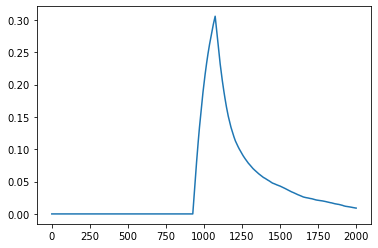

In [167]:
tf.plot()

<AxesSubplot:>

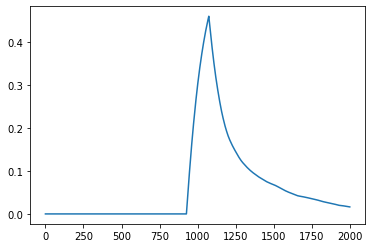

In [168]:
td.plot()

In [145]:
tf.to_csv('foo.csv')

In [129]:
df_seq_region_code

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.027027,0.013514,0.013514,0.013514,0.027027,0.000000,0.013514,0.013514,0.013514
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.026667,0.013333,0.013333,0.013333,0.026667,0.000000,0.013333,0.013333,0.013333
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.026316,0.013158,0.013158,0.013158,0.026316,0.000000,0.013158,0.013158,0.013158
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.025974,0.012987,0.012987,0.012987,0.025974,0.000000,0.012987,0.012987,0.012987
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.038462,0.025641,0.012821,0.025641,0.025641,0.012821,0.025641,0.025641,0.025641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [132]:
df_total_region_code

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.027027,0.027027,0.027027,0.027027,0.027027,0.027027,0.027027,0.027027,0.027027,0.027027
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.026667,0.026667,0.026667,0.026667,0.026667,0.026667,0.026667,0.026667,0.026667,0.026667
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.025974,0.025974,0.025974,0.025974,0.025974,0.025974,0.025974,0.025974,0.025974,0.025974
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_seq_region_code

In [124]:
tf = pd.DataFrame(df_seq_region_)

In [125]:
tf.to_csv('foo.csv')

In [110]:
df_seq_region.iloc[:2].rolling(window=147, min_periods=1, center=True).apply()

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,5.0,2.5,2.5,2.5,2.5,5.0,2.5,5.0,5.0,0.0,...,4.0,4.0,2.0,2.0,0.0,4.0,4.0,0.0,4.0,4.0
1,5.0,2.5,2.5,2.5,2.5,5.0,2.5,5.0,5.0,0.0,...,4.0,4.0,2.0,2.0,0.0,4.0,4.0,0.0,4.0,4.0


In [56]:
print('CALCULATING THE REGION DENSITY')

region_density.index.name = 'region'
region_density_grouped = region_density.groupby('region').sum()
region_density_grouped.reset_index(inplace=True, drop=False)


region_density_grouped.loc[:, 'total_region'] = region_density_grouped.loc[:, COL].sum(axis=1)

total_count_regions = region_density_grouped[['region', 'total_region']]

region_density_grouped.drop(['total_region'], inplace=True, axis=1)
region_density_grouped[COL] = region_density_grouped[COL] / total_records
region_density_melted = pd.melt(region_density_grouped, id_vars=['region'], value_vars=COL)
region_density_melted.rename(columns={'value': 'region_density'}, inplace=True)

region_density_melted['variable'] = region_density_melted['variable'].astype(int)
region_density_melted.rename(columns={'variable': 'position'}, inplace=True)
region_density_melted['position'] = region_density_melted['position'] - 1000


CALCULATING THE REGION DENSITY


In [57]:
nuc_region_data = region_density_melted.groupby('region')['region_density'].rolling(window=147, 
                                                                  min_periods=1, center=True).mean().reset_index()
nuc_region_data.rename(columns={'level_1':'index', 'region_density':'nuc_region_density'}, inplace=True)

region_density_melted['index'] = region_density_melted.index
region_density_melted = region_density_melted.merge(nuc_region_data, on=['index', 'region'], how='left')
region_density_melted.drop(columns=['index'], inplace=True)

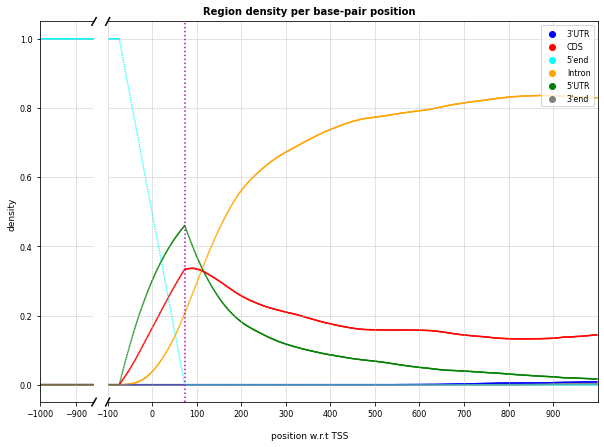

In [59]:


broken_axis_plot(data_ = region_density_melted,
                     plot_title = "Region density per base-pair position",
                     x_title='position w.r.t TSS',
                     y_title = 'density',
                     x_column = 'position',
                     y_column = 'nuc_region_density',
                     hue_column = 'region',
                     save_loc=NUCLO_ELEMENT_DENSITY_LINE_CHART, N=True)


In [ ]:
region_gc_density.index.name = 'region'

region_gc_density_grouped = region_gc_density.groupby('region').sum()
region_gc_density_grouped.reset_index(inplace=True, drop=False)

region_gc_density_grouped['region'] = region_gc_density_grouped['region'].map(OPP_REGION_DICT)
region_gc_density_grouped.loc[:, 'gc_count'] = region_gc_density_grouped.loc[:, COL].sum(axis=1)

region_gc_density_grouped.dropna(subset=['region'], axis=0, inplace=True)
avg_gc_region_df = region_gc_density_grouped[['region', 'gc_count']]
region_gc_density_grouped.drop(['gc_count'], axis=1, inplace=True)

merged_avg_gc_region = avg_gc_region_df.merge(total_count_regions , on='region', how='left')
merged_avg_gc_region['avg_gc'] = merged_avg_gc_region['gc_count'] / merged_avg_gc_region['total_region']
merged_avg_gc_region['avg_gc'] = merged_avg_gc_region['avg_gc'].replace([np.inf, -np.inf], np.nan)


In [237]:
cds_inter_signal_subtracted = pd.read_csv('pd_signal_choice_aa.csv')
cds_inter_signal_subtracted.drop(columns=['Unnamed: 0'], inplace=True)

In [232]:
cds_intra_signal = pd.read_csv('intra_signal.csv')

In [234]:
cds_intra_signal.drop(columns=['Unnamed: 0'], inplace=True)

In [235]:
cds_intra_signal = cds_intra_signal[cds_intra_signal['variable'] == 'CDS_signal']

In [239]:
cds_intra_signal.rename(columns={'value':'syn_signal'}, inplace=True)

C:\Anaconda\envs\un_dna\lib\site-packages\pandas\core\frame.py:5039: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


In [240]:
cds_inter_signal_subtracted = cds_inter_signal_subtracted[['position', 'pd_choice_aa_signal']]

aa_signal = cds_inter_signal_subtracted.merge(cds_intra_signal, on='position', how='left')

aa_signal =  pd.melt(aa_signal, id_vars=['position'],
                     value_vars=['pd_choice_aa_signal', 'syn_signal'])


In [244]:
aa_signal

,position,variable,value
0,-1000,pd_choice_aa_signal,0.000000
1,-999,pd_choice_aa_signal,0.000000
2,-998,pd_choice_aa_signal,0.000000
3,-997,pd_choice_aa_signal,0.000000
4,-996,pd_choice_aa_signal,0.000000
...,...,...,...
3995,995,syn_signal,-0.054397
3996,996,syn_signal,-0.056264
3997,997,syn_signal,-0.059531
3998,998,syn_signal,-0.054597


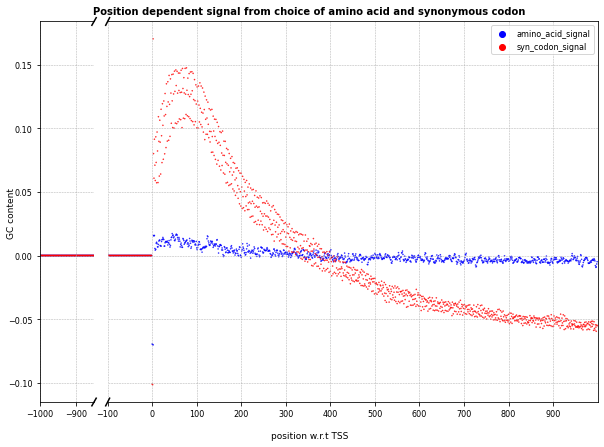

In [247]:
colormap_region = {'pd_choice_aa_signal': 'blue', 'syn_signal': 'red'}
region_labels = {'pd_choice_aa_signal': "amino_acid_signal", 'syn_signal': "syn_codon_signal"}

fig, (ax_1, ax_2) = plt.subplots(1, 2, sharey=True, figsize=(10, 7), gridspec_kw={'width_ratios': [0.1, 0.9]})
fig.subplots_adjust(wspace=0.05)
ax_1.spines.right.set_visible(False)
ax_2.spines.left.set_visible(False)

sns.scatterplot(data=aa_signal, x='position', y='value', hue='variable', fc='none',
                ec=aa_signal['variable'].map(colormap_region),
                palette=colormap_region, s=1, linewidth=0.5, ax=ax_2)
handles, labels = ax_2.get_legend_handles_labels()
new_labels = [region_labels.get(item, item) for item in labels]
ax_2.tick_params(axis='x', labelsize=8)
ax_2.tick_params(axis='y', colors='white')
ax_2.set_xticks(ticks=np.arange(aa_signal['position'].min(), aa_signal['position'].max(), 100))
ax_2.legend(handles=handles, loc='upper right', fontsize=8, labels=new_labels)
ax_2.set_xlim(-100, 1000)
ax_2.set(xlabel=None, ylabel=None)
ax_2.grid(True, linestyle='--', linewidth=0.5, axis='both')

sns.scatterplot(data=aa_signal, x='position', y='value', hue='variable', fc='none',
                ec=aa_signal['variable'].map(colormap_region),
                palette=colormap_region, s=1, linewidth=0.5, ax=ax_1, legend=False)
ax_1.tick_params(axis='both', labelsize=8)
ax_1.set_xticks(ticks=np.arange(aa_signal['position'].min(), aa_signal['position'].max(), 100))
ax_1.set_xlim(-1000, -850)
ax_1.set(xlabel=None, ylabel=None)
ax_1.grid(True, linestyle='--', linewidth=0.5, axis='both')

fig.supxlabel('position w.r.t TSS', fontsize=9, x=0.5, y=0.05)
fig.supylabel('GC content', fontsize=9, y=0.5, x=0.08)
fig.suptitle('Position dependent signal from choice of amino acid and synonymous codon',
             size=10, fontweight='bold', y=0.91, x=0.5)
d = .01
kwargs = dict(transform=ax_1.transAxes, color='k', clip_on=False)
ax_1.plot((1 - d - 3 * d, 1 + d + 3 * d), (-d, +d), **kwargs)  ##bottom left
ax_1.plot((1 - d - 3 * d, 1 + d + 3 * d), (1 - d, 1 + d), **kwargs)  ##top left
kwargs.update(transform=ax_2.transAxes)
ax_2.plot((-d + .6 * d, +d - .6 * d), (1 - d, 1 + d), **kwargs)  ##top right
ax_2.plot((-d + .6 * d, +d - .6 * d), (-d, +d), **kwargs)  ##bottom right


In [293]:
NUC_aa_df = pd.read_csv('NUC_aa_df.csv')
NUC_aa_df.rename(columns={'Unnamed: 0':'position'}, inplace=True)

NUC_aa_gc_count = pd.read_csv('NUC_aa_gc_count.csv')
NUC_aa_gc_count.rename(columns={'Unnamed: 0':'position'}, inplace=True)

In [294]:
NUC_aa_df

,position,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1000.0
1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1000.0
2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1000.0
3,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1000.0
4,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1995,12.192308,3.166667,7.102564,10.846154,5.897436,9.666667,3.487179,5.974359,7.102564,...,0.0,0.0,0.0,0.0,0.076923,16.448718,829.641026,8.064103,2.0,0.0
3996,1996,12.090909,3.181818,7.064935,10.883117,5.922078,9.753247,3.467532,5.961039,7.090909,...,0.0,0.0,0.0,0.0,0.077922,16.402597,829.610390,8.077922,2.0,0.0
3997,1997,12.026316,3.184211,7.026316,10.986842,5.921053,9.802632,3.447368,5.973684,7.065789,...,0.0,0.0,0.0,0.0,0.078947,16.368421,829.565789,8.092105,2.0,0.0
3998,1998,12.000000,3.200000,7.013333,11.000000,5.933333,9.800000,3.440000,6.000000,7.053333,...,0.0,0.0,0.0,0.0,0.080000,16.333333,829.506667,8.106667,2.0,0.0


In [295]:
AA_DICT= {'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7,
           'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14,
           'R': 15, 'S': 16, 'T': 17, 'U': 18, 'V': 19, 'W': 20,
           'Y': 21, 'X': 22, 'B': 23, 'Z': 24, 'J': 25, 'O': 26,
           'x': 27, 'u': 28, 'i': 29, 'd': 30, 'f': 31, 'z': 32}
OPP_AA_DICT = {v: k for k, v in AA_DICT.items()}

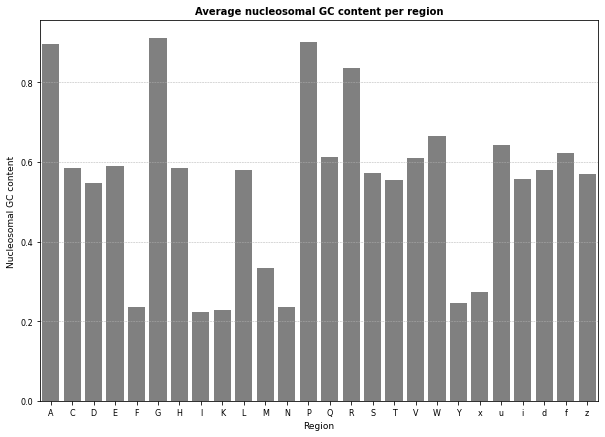

In [298]:
aa_code = NUC_aa_df.columns
# NUC_aa_df['position'] = NUC_aa_df.index
# NUC_aa_gc_count['position'] = NUC_aa_gc_count.index

NUC_aa_df = NUC_aa_df.groupby(['position']).sum().reset_index()
NUC_aa_gc_count = NUC_aa_gc_count.groupby(['position']).sum().reset_index()

nuc_total_gc = NUC_aa_gc_count.sum(axis=0).reset_index()
nuc_total_gc.rename(columns={0: 'total_gcs', 'index': 'amino_acid'}, inplace=True)

nuc_total_bases = NUC_aa_df.sum(axis=0).reset_index()
nuc_total_bases.rename(columns={0: 'total_bases', 'index': 'amino_acid'}, inplace=True)

nuc_avg_gc_aa = nuc_total_gc.merge(nuc_total_bases, on='amino_acid', how='left')
nuc_avg_gc_aa['avg_GC'] = nuc_avg_gc_aa['total_gcs'] / nuc_avg_gc_aa['total_bases']

nuc_avg_gc_aa = nuc_avg_gc_aa[nuc_avg_gc_aa['amino_acid']!='position']
nuc_avg_gc_aa['amino_acid'] = nuc_avg_gc_aa['amino_acid'].astype(int)

nuc_avg_gc_aa['amino_acid'] = nuc_avg_gc_aa['amino_acid'].map(OPP_AA_DICT)
nuc_avg_gc_aa.dropna(inplace=True)

# nuc_avg_gc_aa.to_csv(NUCLO_AVG_GC_PER_REGION_FILE)

fig, ax3 = plt.subplots(figsize=(10, 7))
sns.barplot(data=nuc_avg_gc_aa,
            x="amino_acid", y="avg_GC", ax=ax3, color='gray')
plt.xlabel("Region", fontsize=9)
plt.ylabel("Nucleosomal GC content", fontsize=9)
plt.title("Average nucleosomal GC content per region", size=10, fontweight='bold')
plt.tick_params(axis='both', labelrotation=0, labelsize=8)
plt.grid(linestyle='--', linewidth=0.5, axis='y')
plt.show()
# plt.savefig(NUCLO_AVG_GC_REGION_CHART)


In [326]:
NUC_aa_gc_count

,position,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1036.067568
1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1036.320000
2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1036.289474
3,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1036.532468
4,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1036.794872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,18.294872,3.525641,6.730769,11.358974,2.423077,16.179487,3.923077,2.307692,3.128205,...,0.0,0.0,0.0,0.0,0.025641,17.897436,835.371795,5.935897,4.269231,0.000000
1996,1996,18.194805,3.532468,6.740260,11.376623,2.428571,16.233766,3.909091,2.272727,3.129870,...,0.0,0.0,0.0,0.0,0.025974,17.857143,835.779221,5.935065,4.259740,0.000000
1997,1997,18.118421,3.552632,6.723684,11.368421,2.394737,16.276316,3.907895,2.250000,3.118421,...,0.0,0.0,0.0,0.0,0.026316,17.789474,835.710526,5.947368,4.263158,0.000000
1998,1998,18.146667,3.546667,6.693333,11.306667,2.400000,16.293333,3.853333,2.266667,3.133333,...,0.0,0.0,0.0,0.0,0.026667,17.826667,835.560000,5.960000,4.253333,0.000000


In [301]:
nuclo_aa_density_melted =  pd.read_csv('aa_density.csv')
nuclo_aa_density_melted.drop(columns=['Unnamed: 0'], inplace=True)

In [302]:
nuclo_aa_density_melted

,amino_acid,position,aa_density,nuc_aa_density
0,A,-1000,0.0000,0.000000
1,UF,-1000,1.0000,1.000000
2,Stop,-1000,0.0000,0.000000
3,UUTR,-1000,0.0000,0.000000
4,Intron,-1000,0.0000,0.000000
...,...,...,...,...
51995,C,999,0.0035,0.003034
51996,A,999,0.0105,0.010878
51997,Stop,999,0.0000,0.000041
51998,N,999,0.0055,0.004331


In [315]:
def broken_axis_plot(data_, plot_title, x_title, y_title, x_column, y_column, hue_column, save_loc):
    colormap_region = {'non-CDS_signal': 'blue', 'CDS_signal': 'red'}
    region_labels = {'non-CDS_signal': "non-CDS", 'CDS_signal': "CDS"}

    fig, (ax_1, ax_2) = plt.subplots(1, 2, sharey=True, figsize=(10, 7), gridspec_kw={'width_ratios': [0.1, 0.9]})
    fig.subplots_adjust(wspace=0.05)
    ax_1.spines.right.set_visible(False)
    ax_2.spines.left.set_visible(False)

    sns.scatterplot(data=data_, x=x_column, y=y_column, hue=hue_column, fc='none',
                    ec=data_[hue_column].map(colormap_region),
                    palette=colormap_region, s=1, linewidth=0.5, ax=ax_2)
    handles, labels = ax_2.get_legend_handles_labels()
    new_labels = [region_labels.get(item, item) for item in labels]
    ax_2.tick_params(axis='x', labelsize=8)
    ax_2.tick_params(axis='y', colors='white')
    ax_2.set_xticks(ticks=np.arange(data_[x_column].min(), data_[x_column].max(), 100))
    ax_2.legend(handles=handles, loc='upper right', fontsize=8, labels=new_labels)
    ax_2.set_xlim(-100, 1000)
    ax_2.set(xlabel=None, ylabel=None)
    ax_2.grid(True, linestyle='--', linewidth=0.5, axis='both')

    sns.scatterplot(data=data_, x=x_column, y=y_column, hue=hue_column, fc='none',
                    ec=data_[hue_column].map(colormap_region),
                    palette=colormap_region, s=1, linewidth=0.5, ax=ax_1, legend=False)
    ax_1.tick_params(axis='both', labelsize=8)
    ax_1.set_xticks(ticks=np.arange(data_[x_column].min(), data_[x_column].max(), 100))
    ax_1.set_xlim(-1000, -850)
    ax_1.set(xlabel=None, ylabel=None)
    ax_1.grid(True, linestyle='--', linewidth=0.5, axis='both')

    fig.supxlabel(x_title, fontsize=9, x=0.5, y=0.05)
    fig.supylabel(y_title, fontsize=9, y=0.5, x=0.08)
    fig.suptitle(plot_title, size=10, fontweight='bold', y=0.91, x=0.5)
    d = .01
    kwargs = dict(transform=ax_1.transAxes, color='k', clip_on=False)
    ax_1.plot((1 - d - 3 * d, 1 + d + 3 * d), (-d, +d), **kwargs)  ##bottom left
    ax_1.plot((1 - d - 3 * d, 1 + d + 3 * d), (1 - d, 1 + d), **kwargs)  ##top left
    kwargs.update(transform=ax_2.transAxes)
    ax_2.plot((-d + .6 * d, +d - .6 * d), (1 - d, 1 + d), **kwargs)  ##top right
    ax_2.plot((-d + .6 * d, +d - .6 * d), (-d, +d), **kwargs)  ##bottom right

#     plt.savefig(save_loc)
    plt.show()
    return None


In [311]:
AA_include = ['A', 'C', 'D', 'E', 'F', 'G', 'H',
                'I', 'K', 'L', 'M', 'N', 'P', 'Q',
                'R', 'S', 'T', 'U', 'V', 'W',
                'Y', 'X', 'B', 'Z', 'J', 'O', 'Stop']

In [312]:

def grid_plotting(data, plot_title, x_title, y_title, x_column, y_column, save_loc):
    fig, axes = plt.subplots(9, 3, sharey=True, sharex=True, figsize=(20, 30))
    fig.subplots_adjust(wspace=0.1, hspace=0.25)
    aa_ind = 0
    for ax in axes.reshape(-1):
        data_ = data[data['amino_acid'] == str(AA_include[aa_ind])]
        sns.scatterplot(data=data_,
                        x=x_column, y=y_column, fc='none',
                        s=4, linewidth=1, ax=ax, color='red', edgecolor="black")
        # handles, labels = ax.get_legend_handles_labels()
        # new_labels = [region_labels.get(item, item) for item in labels]
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        if len(data_) > 0:
            ax.set_xticks(ticks=np.arange(data_[x_column].min(), data_[x_column].max(), 100))
        # ax.legend(handles=handles, loc='upper right', fontsize=8, labels=new_labels)
        ax.set_xlim(0, 1000, 100)
        ax.set(xlabel=None, ylabel=None)
        ax.grid(True, linestyle='--', linewidth=0.5, axis='both')
        ax.set_title('AMINO ACID = ' + str(AA_include[aa_ind]), size=9)
        aa_ind = aa_ind + 1
    plt.suptitle(plot_title, y=0.92)
    plt.setp(axes[-1, :], xlabel=x_title)
    plt.setp(axes[:, 0], ylabel=y_title)
    plt.show()
    print(save_loc)
#     plt.savefig(save_loc)
    return None

In [313]:
AA_CHOICE_SIGNAL_CHART = ''

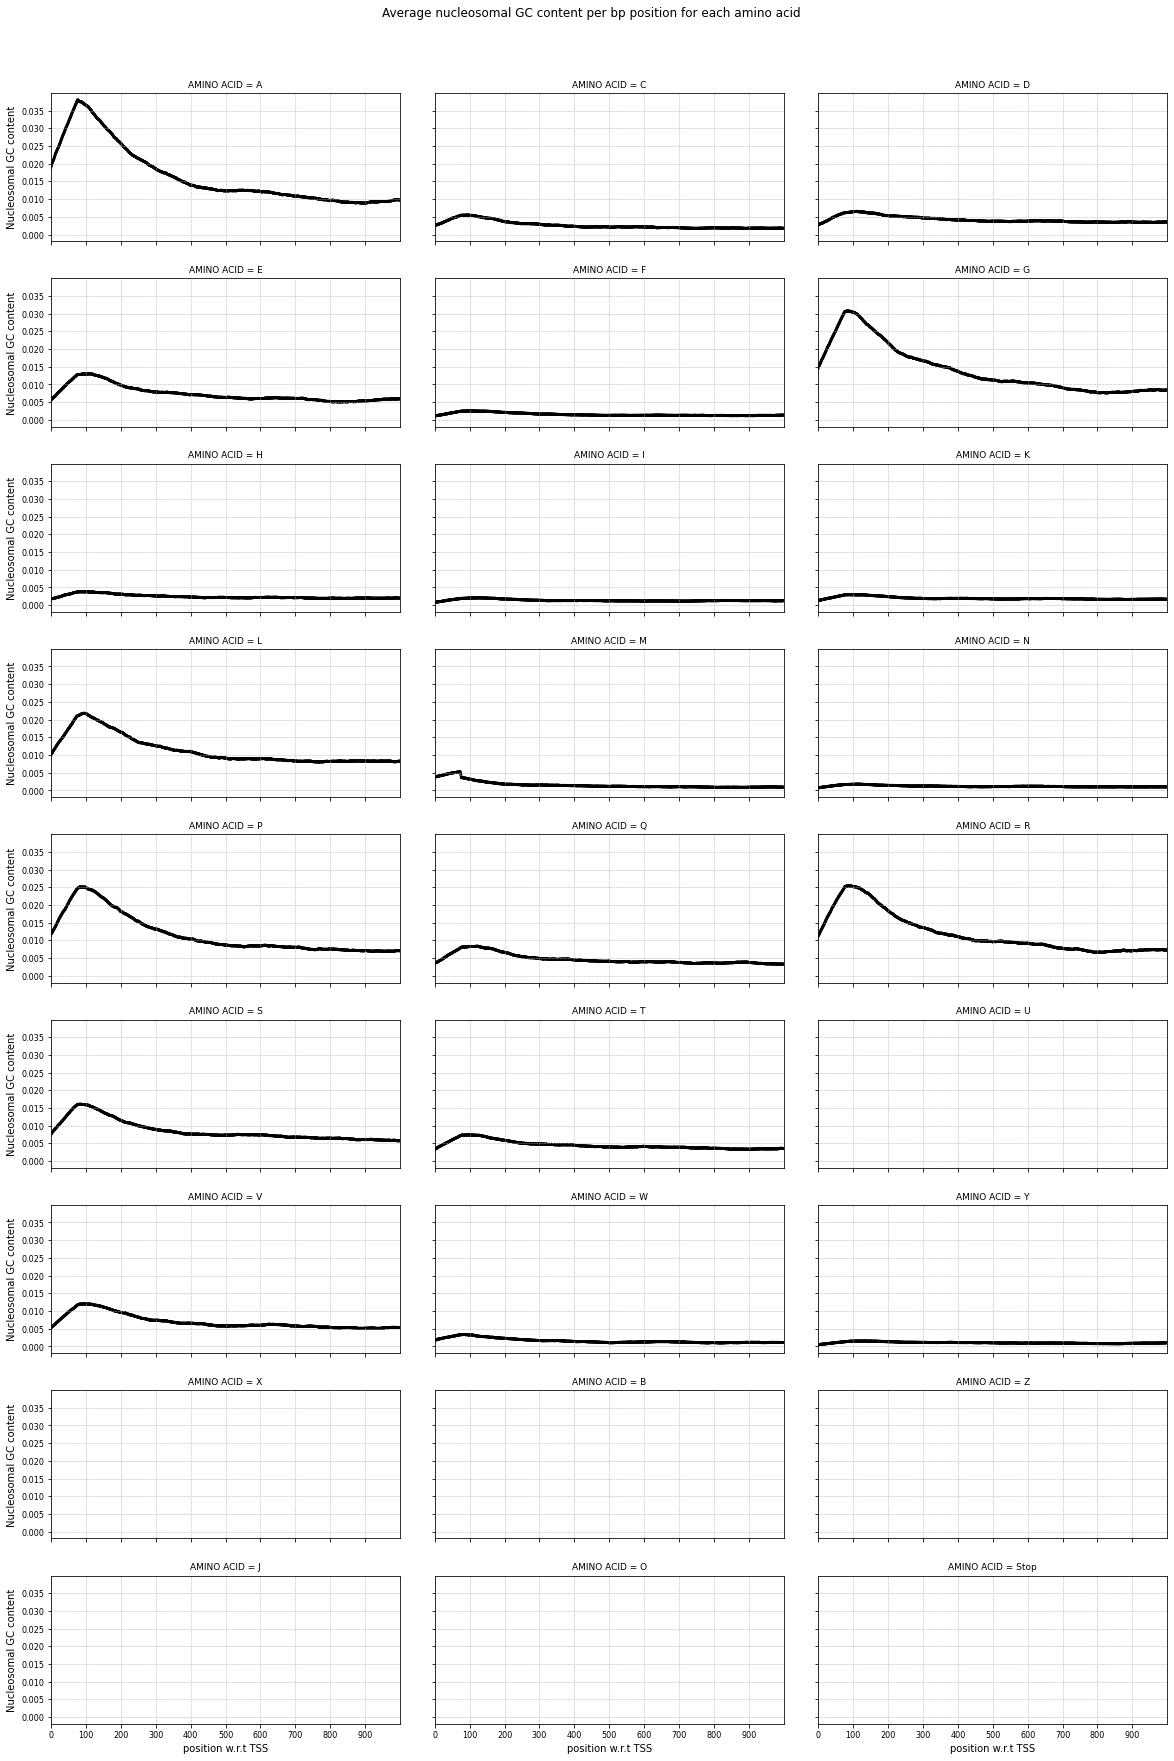

In [303]:
print('CALCULATING THE NUCLEOSOMAL GC CONTENT FROM THE CHOICE OF AMINO ACID FOR EACH AMINO ACID')

nuclo_signal_choice_aa = nuclo_aa_density_melted.merge(nuc_avg_gc_aa[['amino_acid', 'avg_GC']],
                                               on='amino_acid',
                                               how='left')
nuclo_signal_choice_aa['signal'] = nuclo_signal_choice_aa['nuc_aa_density']*nuclo_signal_choice_aa['avg_GC']

# nuclo_signal_choice_aa.to_csv(AA_CHOICE_SIGNAL_FILE)

grid_plotting(data=nuclo_signal_choice_aa,
              plot_title="Average nucleosomal GC content per bp position for each amino acid",
              x_title='position w.r.t TSS',
              y_title='Nucleosomal GC content',
              x_column='position',
              y_column='signal',
              save_loc=AA_CHOICE_SIGNAL_CHART)

CALCULATING THE NUCLEOSOMAL GC CONTENT FROM THE CHOICE OF AMINO ACID FOR EACH AMINO ACID


,amino_acid,position,aa_density,nuc_aa_density,avg_GC,inter_signal
0,A,-1000,0.0000,0.000000,0.895853,0.000000
1,UF,-1000,1.0000,1.000000,NaN,NaN
2,Stop,-1000,0.0000,0.000000,NaN,NaN
3,UUTR,-1000,0.0000,0.000000,NaN,NaN
4,Intron,-1000,0.0000,0.000000,NaN,NaN
...,...,...,...,...,...,...
51995,C,999,0.0035,0.003034,0.585721,0.001777
51996,A,999,0.0105,0.010878,0.895853,0.009745
51997,Stop,999,0.0000,0.000041,NaN,NaN
51998,N,999,0.0055,0.004331,0.234849,0.001017


In [316]:
TOTAL_AA_CHOICE_SIGNAL_CHART = ''

In [322]:
CDS_INTER_REGION_FILE = r"C:\Users\maya620d\PycharmProjects\Multiplexing\Results\/" +GROUP+ '\/' +SPECIES_NAME + r'\pre_mRNA\Files\inter_region_signal_per_region.csv'
pre_mrna_inter_signal_region_dist = pd.read_csv(CDS_INTER_REGION_FILE)
pre_mrna_inter_signal_region_dist

,Unnamed: 0,region,position,region_density,index,avg_gc,signal
0,0,D,-1000,0.0000,0,0.580074,0.000000
1,1,E,-1000,0.0000,1,0.619000,0.000000
2,2,F,-1000,1.0000,2,0.568767,0.568767
3,3,I,-1000,0.0000,3,0.558183,0.000000
4,4,U,-1000,0.0000,4,0.641413,0.000000
...,...,...,...,...,...,...,...
11995,11995,D,999,0.0060,11995,0.580074,0.003480
11996,11996,E,999,0.1395,11996,0.619000,0.086350
11997,11997,F,999,0.0000,11997,0.568767,0.000000
11998,11998,I,999,0.8370,11998,0.558183,0.467199


In [318]:
NUCLO_CDS_INTER_REGION_FILE = r"C:\Users\maya620d\PycharmProjects\Multiplexing\Results\/" +GROUP+ '\/' +SPECIES_NAME + r'\NUCLO\pre_mRNA\Files\inter_region_signal_per_region.csv'


In [320]:
pre_mrna_NUCLO_inter_signal_region_dist = pd.read_csv(NUCLO_CDS_INTER_REGION_FILE)
pre_mrna_NUCLO_inter_signal_region_dist

,Unnamed: 0,region,position,region_density,nuc_region_density,avg_GC,inter_signal
0,0,D,-1000,0.0000,0.000000,0.579983,0.000000
1,1,E,-1000,0.0000,0.000000,0.619075,0.000000
2,2,F,-1000,1.0000,1.000000,0.568786,0.568786
3,3,I,-1000,0.0000,0.000000,0.558228,0.000000
4,4,U,-1000,0.0000,0.000000,0.641438,0.000000
...,...,...,...,...,...,...,...
11995,11995,D,999,0.0060,0.005561,0.579983,0.003480
11996,11996,E,999,0.1395,0.136203,0.619075,0.086361
11997,11997,F,999,0.0000,0.000000,0.568786,0.000000
11998,11998,I,999,0.8370,0.838635,0.558228,0.467237


CALCULATING THE TOTAL SIGNAL FROM CHOICE OF AMINO ACID


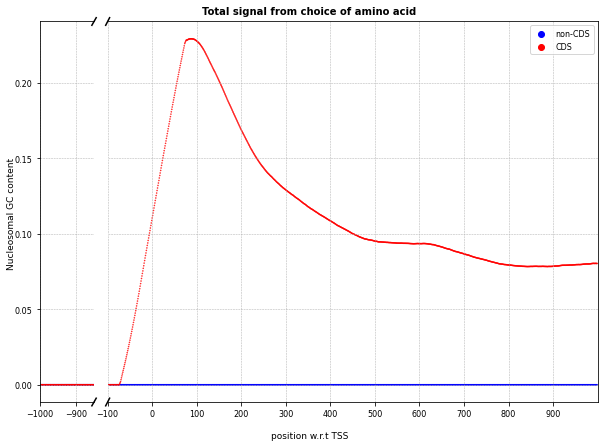

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


      position  CDS_signal region  nuc_region_density  inter_signal
0        -1000    0.000000      E            0.000000      0.000000
1         -999    0.000000      E            0.000000      0.000000
2         -998    0.000000      E            0.000000      0.000000
3         -997    0.000000      E            0.000000      0.000000
4         -996    0.000000      E            0.000000      0.000000
...        ...         ...    ...                 ...           ...
1995       995    0.080393      E            0.136186      0.086051
1996       996    0.080381      E            0.136188      0.086670
1997       997    0.080353      E            0.136191      0.086361
1998       998    0.080338      E            0.136200      0.086670
1999       999    0.080351      E            0.136203      0.086361

[2000 rows x 5 columns]


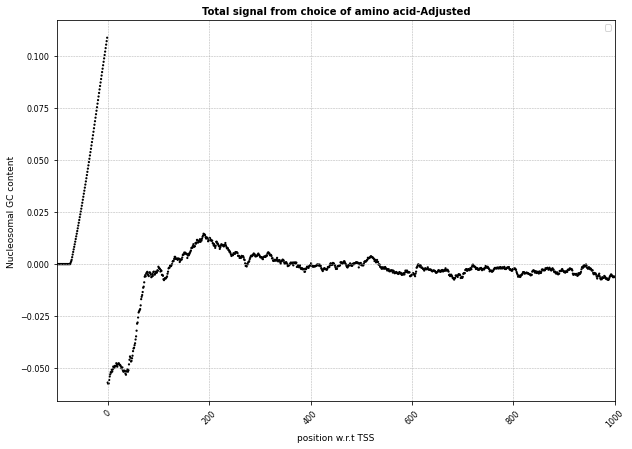

In [325]:

print('CALCULATING THE TOTAL SIGNAL FROM CHOICE OF AMINO ACID')

nuclo_cds_inter_signal = nuclo_signal_choice_aa[nuclo_signal_choice_aa['amino_acid'].isin(AA_include)]
nuclo_cds_inter_signal_grouped = nuclo_cds_inter_signal.groupby('position')['signal'].sum()
nuclo_cds_inter_signal_grouped = nuclo_cds_inter_signal_grouped.reset_index()
nuclo_cds_inter_signal_grouped.rename(columns={'signal': 'CDS_signal'}, inplace=True)

nuclo_not_cds_inter_signal = nuclo_signal_choice_aa[nuclo_signal_choice_aa['amino_acid'].isin(['UF', 'Intron', 'UUTR', 'DUTR', 'DF'])]
nuclo_not_cds_inter_signal_grouped = nuclo_not_cds_inter_signal.groupby('position')['signal'].sum()
nuclo_not_cds_inter_signal_grouped = nuclo_not_cds_inter_signal_grouped.reset_index()
nuclo_not_cds_inter_signal_grouped.rename(columns={'signal':'non-CDS_signal'}, inplace=True)
nuclo_total_inter_signal = nuclo_not_cds_inter_signal_grouped.merge(nuclo_cds_inter_signal_grouped, on='position', how='left')
nuclo_total_inter_signal = pd.melt(nuclo_total_inter_signal,
                             id_vars=['position'],
                             value_vars=['non-CDS_signal', 'CDS_signal'])

# nuclo_total_inter_signal.to_csv(TOTAL_AA_CHOICE_SIGNAL_FILE)
broken_axis_plot(data_=nuclo_total_inter_signal,
                 plot_title="Total signal from choice of amino acid",
                 x_title='position w.r.t TSS',
                 y_title='Nucleosomal GC content',
                 x_column='position',
                 y_column='value',
                 hue_column='variable',
                 save_loc=TOTAL_AA_CHOICE_SIGNAL_CHART)

####### Subtract the inter region signal from the choice of amino acid signal to get the position dependence effect.

pre_mrna_NUCLO_inter_signal_region_dist = pd.read_csv(NUCLO_CDS_INTER_REGION_FILE)
pre_mrna_NUCLO_inter_signal_region_dist.drop(columns=['Unnamed: 0', 'region_density', 'avg_GC'], inplace=True)
nuclo_cds_inter_signal_subtracted = nuclo_cds_inter_signal_grouped.merge(pre_mrna_NUCLO_inter_signal_region_dist[pre_mrna_NUCLO_inter_signal_region_dist['region']=='E'],
                                                                   on=['position'],
                                                                   how='left')
print(nuclo_cds_inter_signal_subtracted)
nuclo_cds_inter_signal_subtracted['pd_choice_aa_signal'] = nuclo_cds_inter_signal_subtracted['CDS_signal'] - nuclo_cds_inter_signal_subtracted['inter_signal']

# nuclo_cds_inter_signal_subtracted.to_csv(CORRECTED_TOTAL_AA_CHOICE_SIGNAL_FILE)

# broken_axis_plot(data_=cds_inter_signal_subtracted,
#                  plot_title="Total signal from choice of amino acid",
#                  x_title='position w.r.t TSS',
#                  y_title='GC content',
#                  x_column='position',
#                  y_column='pd_choice_aa_signal',
#                  hue_column='variable',
#                  save_loc=CORRECTED_TOTAL_AA_CHOICE_SIGNAL_CHART)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=nuclo_cds_inter_signal_subtracted[nuclo_cds_inter_signal_subtracted['position'] >= -100], x='position', y='pd_choice_aa_signal',
                fc='none', s=1.5, linewidth=1, edgecolor="black")

plt.xlabel("position w.r.t TSS", fontsize=9)
plt.ylabel("Nucleosomal GC content", fontsize=9)
# plt.xticks(ticks=np.arange(-1000, 1000, 100))
plt.tick_params(axis='x', labelrotation=45, labelsize=8)
plt.tick_params(axis='y', labelsize=8)
plt.title("Total signal from choice of amino acid-Adjusted", size=10, fontweight='bold')
plt.xlim(-100, 1000, 100)
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(handletextpad=0, loc='upper right', markerscale=0.5, fontsize=8)
plt.show()
# plt.savefig(CORRECTED_TOTAL_AA_CHOICE_SIGNAL_CHART)


In [ ]:

#

In [333]:
pd.melt(NUC_aa_gc_count, id_vars='position')

,position,variable,value
0,0,1,0.0
1,1,1,0.0
2,2,1,0.0
3,3,1,0.0
4,4,1,0.0
...,...,...,...
63995,1995,32,0.0
63996,1996,32,0.0
63997,1997,32,0.0
63998,1998,32,0.0


In [346]:
NUC_aa_gc_count_melted = pd.melt(NUC_aa_gc_count, id_vars='position')
NUC_aa_gc_count_melted.rename(columns={'variable':'amino_acid'}, inplace=True)
NUC_aa_gc_count_melted['amino_acid'] = NUC_aa_gc_count_melted['amino_acid'].astype(int)
NUC_aa_gc_count_melted['amino_acid'] = NUC_aa_gc_count_melted['amino_acid'].map(OPP_AA_DICT)
NUC_aa_gc_count_melted['value'] = NUC_aa_gc_count_melted['value']/2000

NUC_aa_gc_count_melted.rename(columns={'value':'syn_signal'}, inplace=True)
NUC_aa_gc_count_melted['position'] = NUC_aa_gc_count_melted['position'].astype(int)
NUC_aa_gc_count_melted['position'] = NUC_aa_gc_count_melted['position'] - 1000

# NUC_aa_gc_count_melted.to_csv(SYN_CODON_SIGNAL_FILE)

In [347]:
NUC_aa_gc_count_melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   position    64000 non-null  int64  
 1   amino_acid  64000 non-null  object 
 2   value       64000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.5+ MB


In [350]:
NUC_aa_gc_count_melted

,position,amino_acid,syn_signal
0,-1000,A,0.0
1,-999,A,0.0
2,-998,A,0.0
3,-997,A,0.0
4,-996,A,0.0
...,...,...,...
63995,995,z,0.0
63996,996,z,0.0
63997,997,z,0.0
63998,998,z,0.0


In [351]:

def make_nan(x, value_col):
    if x['amino_acid'] == 'UF' and x['position']>=0:
        return np.nan
    elif x['amino_acid'] != 'UF' and x['position']<0:
        return np.nan
    else: return x[value_col]

In [353]:
CEN_SYN_CODON_SIGNAL_CHART = ''

CALCULATING THE MEAN CENTERED SIGNAL FROM THE SYNONYMOUS CODONS FOR EACH AMINO ACID


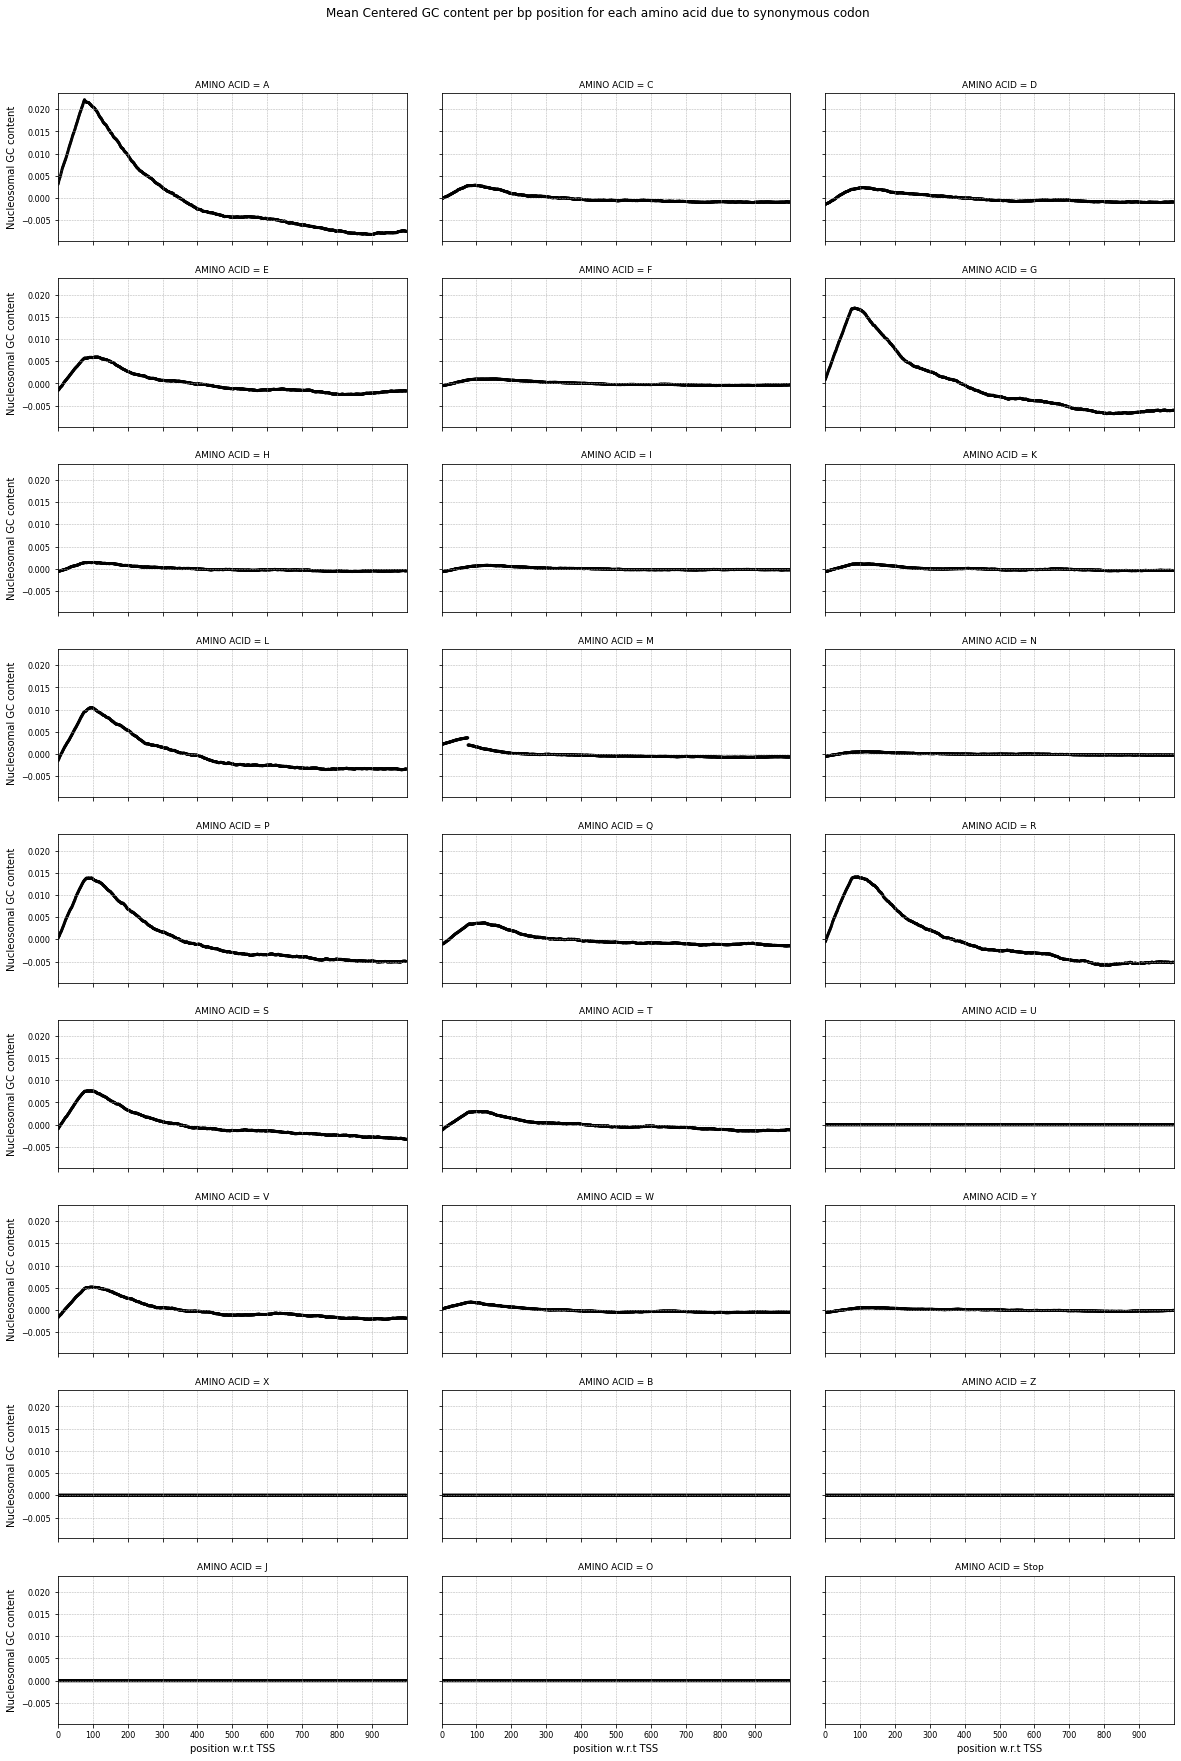

In [354]:
print('CALCULATING THE MEAN CENTERED SIGNAL FROM THE SYNONYMOUS CODONS FOR EACH AMINO ACID')

NUC_aa_gc_count_melted['syn_signal'] = NUC_aa_gc_count_melted.apply(make_nan, value_col='syn_signal', axis=1)

nuc_syn_mean_data = NUC_aa_gc_count_melted.groupby(['amino_acid'])['syn_signal'].mean()
nuc_syn_mean_data = nuc_syn_mean_data.reset_index()

nuc_syn_mean_data.rename(columns={'syn_signal': 'mean_syn_signal'}, inplace=True)

nuc_cent_aa_gc_density_grouped_melted = NUC_aa_gc_count_melted.merge(nuc_syn_mean_data, on='amino_acid', how='left')
nuc_cent_aa_gc_density_grouped_melted['cent_syn_signal'] = nuc_cent_aa_gc_density_grouped_melted['syn_signal'] - nuc_cent_aa_gc_density_grouped_melted['mean_syn_signal']

# nuc_cent_aa_gc_density_grouped_melted.to_csv(CEN_SYN_CODON_SIGNAL_FILE)

grid_plotting(data=nuc_cent_aa_gc_density_grouped_melted,
              plot_title="Mean Centered GC content per bp position for each amino acid due to synonymous codon",
              x_title='position w.r.t TSS',
              y_title='Nucleosomal GC content',
              x_column='position',
              y_column='cent_syn_signal',
              save_loc=CEN_SYN_CODON_SIGNAL_CHART)

In [355]:
NUC_aa_gc_count_melted

,position,amino_acid,syn_signal
0,-1000,A,NaN
1,-999,A,NaN
2,-998,A,NaN
3,-997,A,NaN
4,-996,A,NaN
...,...,...,...
63995,995,z,0.0
63996,996,z,0.0
63997,997,z,0.0
63998,998,z,0.0


In [356]:
nuclo_aa_density_melted

,amino_acid,position,aa_density,nuc_aa_density
0,A,-1000,0.0000,0.000000
1,UF,-1000,1.0000,1.000000
2,Stop,-1000,0.0000,0.000000
3,UUTR,-1000,0.0000,0.000000
4,Intron,-1000,0.0000,0.000000
...,...,...,...,...
51995,C,999,0.0035,0.003034
51996,A,999,0.0105,0.010878
51997,Stop,999,0.0000,0.000041
51998,N,999,0.0055,0.004331


In [357]:
print('CALCULATING THE NORMALISED GC CONTENT FROM THE CHOICE OF SYNONYMOUS CODON')


NUC_aa_gc_count_melted_joined_nuc_aa_den = NUC_aa_gc_count_melted.merge(nuclo_aa_density_melted,
                                                                                 on=['amino_acid', 'position'],
                                                                                 how='left')
NUC_aa_gc_count_melted_joined_nuc_aa_den['normalised_syn_signal'] = NUC_aa_gc_count_melted_joined_nuc_aa_den['syn_signal']/\
                                                                      NUC_aa_gc_count_melted_joined_nuc_aa_den['nuc_aa_density']

NUC_aa_gc_count_melted_joined_nuc_aa_den['normalised_syn_signal'].fillna(0, inplace=True)
# NUC_aa_gc_count_melted_joined_nuc_aa_den.to_csv(NORMALISED_SYN_CODON_SIGNAL_FILE)

# grid_plotting(data=aa_gc_density_grouped_melted_joined_aa_den,
#               plot_title="Normalised GC content per bp position for each amino acid due to synonymous codon",
#               x_title='position w.r.t TSS',
#               y_title='GC content',
#               x_column='position',
#               y_column='normalised_syn_signal',
#               save_loc=NORMALISED_SYN_CODON_SIGNAL_CHART)

CALCULATING THE NORMALISED GC CONTENT FROM THE CHOICE OF SYNONYMOUS CODON


In [358]:
NUC_aa_gc_count_melted_joined_nuc_aa_den

,position,amino_acid,syn_signal,aa_density,nuc_aa_density,normalised_syn_signal
0,-1000,A,NaN,0.0,0.0,0.0
1,-999,A,NaN,0.0,0.0,0.0
2,-998,A,NaN,0.0,0.0,0.0
3,-997,A,NaN,0.0,0.0,0.0
4,-996,A,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...
63995,995,z,0.0,NaN,NaN,0.0
63996,996,z,0.0,NaN,NaN,0.0
63997,997,z,0.0,NaN,NaN,0.0
63998,998,z,0.0,NaN,NaN,0.0


CALCULATING THE MEAN CENTERED NORMALISED GC CONTENT FROM THE CHOICE OF SYNONYMOUS CODON


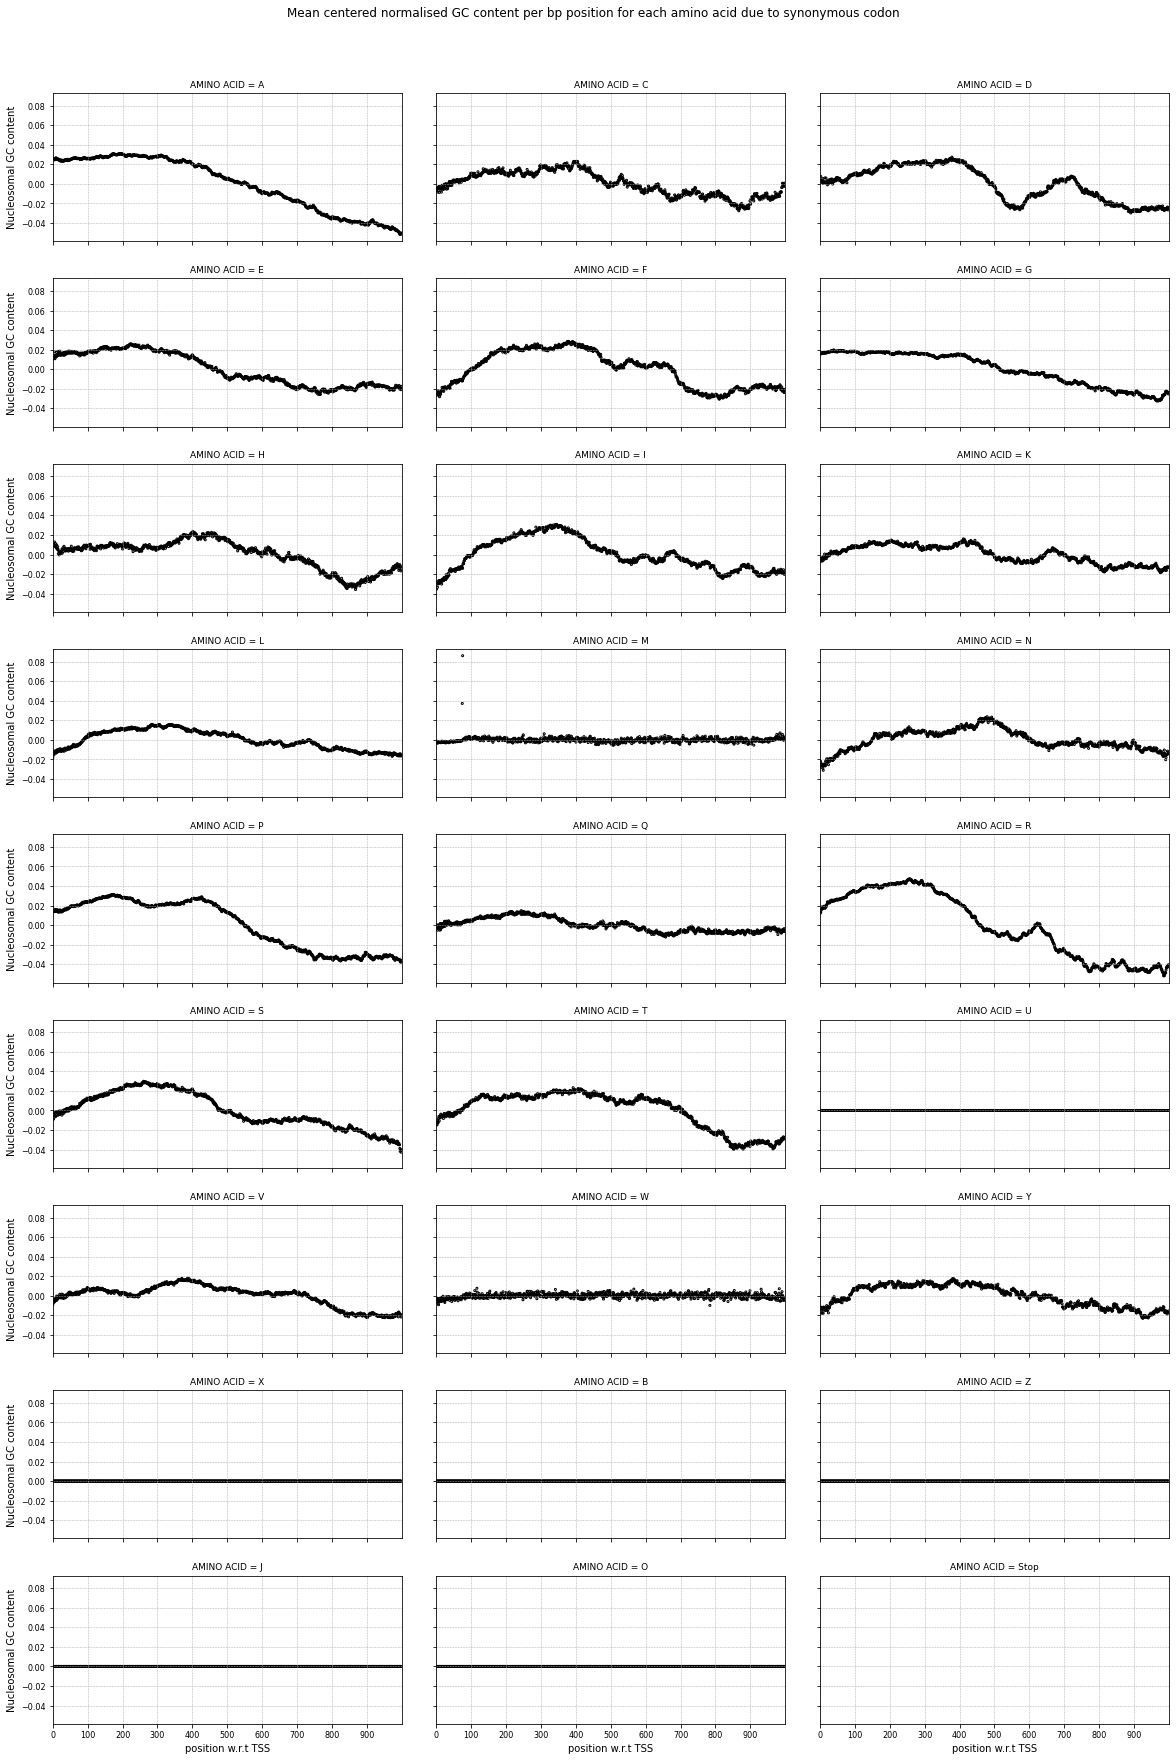

In [360]:
print('CALCULATING THE MEAN CENTERED NORMALISED GC CONTENT FROM THE CHOICE OF SYNONYMOUS CODON')


NUC_aa_gc_count_melted_joined_nuc_aa_den['normalised_syn_signal'] = NUC_aa_gc_count_melted_joined_nuc_aa_den.apply(make_nan,
                                                                                          value_col='normalised_syn_signal',
                                                                                          axis=1)
nuc_norm_intra_mean_data = NUC_aa_gc_count_melted_joined_nuc_aa_den.groupby(['amino_acid'])[
    'normalised_syn_signal'].mean()
nuc_norm_intra_mean_data = nuc_norm_intra_mean_data.reset_index()
nuc_norm_intra_mean_data.rename(columns={'normalised_syn_signal': 'mean_intra_signal'}, inplace=True)

cent_NUC_aa_gc_count_melted_joined_nuc_aa_den = NUC_aa_gc_count_melted_joined_nuc_aa_den.merge(
    nuc_norm_intra_mean_data, on='amino_acid',
    how='left')

cent_NUC_aa_gc_count_melted_joined_nuc_aa_den['cent_norm_intra_signal'] = \
    cent_NUC_aa_gc_count_melted_joined_nuc_aa_den['normalised_syn_signal'] - \
    cent_NUC_aa_gc_count_melted_joined_nuc_aa_den[
        'mean_intra_signal']
# cent_NUC_aa_gc_count_melted_joined_nuc_aa_den.to_csv(CENT_NORMALISED_SYN_CODON_SIGNAL_FILE)

grid_plotting(data=cent_NUC_aa_gc_count_melted_joined_nuc_aa_den,
              plot_title= "Mean centered normalised GC content per bp position for each amino acid due to synonymous codon",
              x_title='position w.r.t TSS',
              y_title='Nucleosomal GC content',
              x_column='position',
              y_column='cent_norm_intra_signal',
              save_loc=CENT_NORMALISED_SYN_CODON_SIGNAL_CHART)



In [361]:
cent_NUC_aa_gc_count_melted_joined_nuc_aa_den

,position,amino_acid,syn_signal,aa_density,nuc_aa_density,normalised_syn_signal,mean_intra_signal,cent_norm_intra_signal
0,-1000,A,NaN,0.0,0.0,NaN,0.88503,NaN
1,-999,A,NaN,0.0,0.0,NaN,0.88503,NaN
2,-998,A,NaN,0.0,0.0,NaN,0.88503,NaN
3,-997,A,NaN,0.0,0.0,NaN,0.88503,NaN
4,-996,A,NaN,0.0,0.0,NaN,0.88503,NaN
...,...,...,...,...,...,...,...,...
63995,995,z,0.0,NaN,NaN,0.0,0.00000,0.0
63996,996,z,0.0,NaN,NaN,0.0,0.00000,0.0
63997,997,z,0.0,NaN,NaN,0.0,0.00000,0.0
63998,998,z,0.0,NaN,NaN,0.0,0.00000,0.0
